# EXPERIMENT: EXP-VIT-SCRATCH-5SEEDS-002

## Vision Transformer (ViT) Scratch — 5-Seed Robustness Baseline

Notebook này dùng **cùng protocol khoa học và cùng format archive** như ResNet50 và DenseNet121:

- Dataset cố định: `Cashew_dataV03`
- Cùng Train / Validation / Test split cho mọi seed
- 5 seeds: `[42, 123, 2026, 3407, 7777]`
- Không đổi hyperparameters giữa các seed
- Checkpoint chọn theo **minimum validation loss**
- Test Set mặc định bị khóa
- Không chọn seed tốt nhất dựa trên Test
- Báo cáo `Mean ± sample Standard Deviation (ddof=1)`
- Figure so sánh 5 seed phải **đặt cạnh nhau trong cùng một panel**

## ViT baseline

```text
Input                 : 224 × 224 × 3
Patch size            : 16 × 16
Patch tokens          : 196
Projection dimension  : 64
Transformer blocks    : 8
Attention heads       : 4
Transformer MLP       : 128
Attention dropout     : 0.10
Transformer dropout   : 0.10
Classifier head       : Dense(256, GELU) + Dropout(0.40)
Optimizer             : AdamW
Initial LR            : 3e-4
Weight decay          : 1e-4
Batch size            : 32
Max epochs            : 60
```

Đây là **ViT train from scratch**, không dùng pretrained weights.

## Dataset

| Class | Train | Val | Test | Total |
|---|---:|---:|---:|---:|
| anthracnose | 1096 | 313 | 156 | 1565 |
| healthy | 818 | 225 | 128 | 1171 |
| leaf_miner | 919 | 262 | 131 | 1312 |
| not_cashew_leaf | 1101 | 314 | 157 | 1572 |
| red_rust | 1115 | 319 | 159 | 1593 |
| **TOTAL** | **5049** | **1433** | **731** | **7213** |

## Figure format

```text
figures/panels/
├── training_curves_5seeds_panel.png
├── validation_confusion_matrices_5seeds_panel.png
├── test_confusion_matrices_5seeds_panel.png
└── test_confusion_matrices_normalized_5seeds_panel.png
```

`training_curves_5seeds_panel.png` dùng bố cục **2 hàng × 5 cột**:
- hàng 1: Accuracy
- hàng 2: Loss
- mỗi cột: một seed

## Archive dùng lại cho YOLO

FULL ZIP lưu cả 5 best checkpoints và:

```text
model_package/
├── deployment_model.keras
├── vit_token_feature_extractor.keras
├── vit_embedding_model.keras
├── deployment_metadata.json
└── label_map.json
```

Deployment seed được chọn bằng **Validation Macro-F1**, không dùng Test.

Google Drive archive target:

```text
https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing
```

In [1]:

# ============================================================
# 01. IMPORT LIBRARIES
# ============================================================

import os
import sys
import io
import gc
import json
import time
import random
import shutil
import platform
import zipfile
import hashlib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
)

from IPython.display import display
import ipywidgets as widgets

print("Imports completed.")


Imports completed.


In [2]:

# ============================================================
# 02. ENVIRONMENT INFORMATION
# ============================================================

print(f"Date              : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python            : {sys.version.split()[0]}")
print(f"TensorFlow        : {tf.__version__}")
print(f"Keras             : {keras.__version__ if hasattr(keras, '__version__') else 'tf.keras'}")
print(f"Platform          : Kaggle")
print(f"OS                : {platform.platform()}")

gpus = tf.config.list_physical_devices("GPU")
print(f"GPU Count         : {len(gpus)}")

for i, gpu in enumerate(gpus):
    print(f"GPU {i}             : {gpu}")

if len(gpus) >= 2:
    strategy = tf.distribute.MirroredStrategy()
elif len(gpus) == 1:
    strategy = tf.distribute.OneDeviceStrategy(device="/GPU:0")
else:
    strategy = tf.distribute.OneDeviceStrategy(device="/CPU:0")

print(f"Strategy          : {strategy.__class__.__name__}")
print(f"Replicas          : {strategy.num_replicas_in_sync}")


Date              : 2026-09-21 17:58:09
Python            : 3.12.13
TensorFlow        : 2.20.0
Keras             : 3.13.2
Platform          : Kaggle
OS                : Linux-6.12.90+-x86_64-with-glibc2.35
GPU Count         : 2
GPU 0             : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU 1             : PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Strategy          : MirroredStrategy
Replicas          : 2


I0000 00:00:1790013491.258150      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790013491.261419      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# ============================================================
# 03. CONFIGURATION
# ============================================================

EXPERIMENT_ID = "EXP-VIT-SCRATCH-5SEEDS-003"
DATASET_VERSION = "Cashew_dataV04"

DRIVE_TARGET_URL = (
    "https://drive.google.com/drive/folders/"
    "1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing"
)
DRIVE_TARGET_FOLDER_ID = "1it9ayE473c0lLgxhiNnguqIkKtceI5zf"

EXPECTED_CLASSES = [
    "anthracnose",
    "healthy",
    "leaf_miner",
    "not_cashew_leaf",
    "red_rust",
]

EXPECTED_COUNTS = {
    "anthracnose": {
        "train": 945,
        "val": 294,
        "test": 122,
        "total": 1361,
    },

    "healthy": {
        "train": 806,
        "val": 225,
        "test": 118,
        "total": 1149,
    },

    "leaf_miner": {
        "train": 893,
        "val": 249,
        "test": 132,
        "total": 1274,
    },

    "not_cashew_leaf": {
        "train": 1101,
        "val": 314,
        "test": 157,
        "total": 1572,
    },

    "red_rust": {
        "train": 1077,
        "val": 320,
        "test": 158,
        "total": 1555,
    },
}

EXPECTED_TOTALS = {
    "train": 4822,
    "val": 1402,
    "test": 687,
    "total": 6911,
}

STRICT_DATASET_CHECK = True

# 5-seed protocol
SEEDS = [42, 123, 2026, 3407, 7777]
DEMO_SEED = None

# Training
IMG_SIZE = 224
BATCH_SIZE = 32
MAX_EPOCHS = 60
INITIAL_LR = 3e-4
WEIGHT_DECAY = 1e-4

MODEL_NAME = "VisionTransformer"
TRAINING_MODE = "Scratch"
PRETRAINED_WEIGHTS = None

# ViT architecture
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8
TRANSFORMER_MLP_UNITS = 128
ATTENTION_DROPOUT = 0.10
TRANSFORMER_DROPOUT = 0.10
HEAD_UNITS = 256
HEAD_DROPOUT = 0.40

# Callbacks
EARLY_STOPPING_PATIENCE = 10
REDUCE_LR_PATIENCE = 4
REDUCE_LR_FACTOR = 0.3
MIN_LR = 1e-6

# Locked Test
RUN_FINAL_TEST = True

# Storage
SAVE_BEST_WEIGHTS_ONLY = True
OUT_DIR = Path("/kaggle/working") / EXPERIMENT_ID
AGGREGATE_DIR = OUT_DIR / "aggregate"
PANEL_DIR = OUT_DIR / "figures" / "panels"
MODEL_PACKAGE_DIR = OUT_DIR / "model_package"
CODE_PACKAGE_DIR = OUT_DIR / "code"
ENV_DIR = OUT_DIR / "environment"

for folder in [
    OUT_DIR,
    AGGREGATE_DIR,
    PANEL_DIR,
    MODEL_PACKAGE_DIR,
    CODE_PACKAGE_DIR,
    ENV_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Experiment ID       :", EXPERIMENT_ID)
print("Dataset version     :", DATASET_VERSION)
print("Seeds               :", SEEDS)
print("Image size          :", IMG_SIZE)
print("Patch size          :", PATCH_SIZE)
print("Number of patches   :", NUM_PATCHES)
print("Projection dim      :", PROJECTION_DIM)
print("Attention heads     :", NUM_HEADS)
print("Transformer layers  :", TRANSFORMER_LAYERS)
print("Batch size          :", BATCH_SIZE)
print("Max epochs          :", MAX_EPOCHS)
print("Initial LR          :", INITIAL_LR)
print("Weight decay        :", WEIGHT_DECAY)
print("RUN_FINAL_TEST      :", RUN_FINAL_TEST)
print("Drive target        :", DRIVE_TARGET_URL)

Experiment ID       : EXP-VIT-SCRATCH-5SEEDS-003
Dataset version     : Cashew_dataV04
Seeds               : [42, 123, 2026, 3407, 7777]
Image size          : 224
Patch size          : 16
Number of patches   : 196
Projection dim      : 64
Attention heads     : 4
Transformer layers  : 8
Batch size          : 32
Max epochs          : 60
Initial LR          : 0.0003
Weight decay        : 0.0001
RUN_FINAL_TEST      : True
Drive target        : https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing


In [4]:

# ============================================================
# 04. REPRODUCIBILITY
# ============================================================

def set_global_seed(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Đồng bộ Python / NumPy / TensorFlow theo Keras.
    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

    print(f"Global seed set to: {seed}")


try:
    tf.config.experimental.enable_op_determinism()
    print("Deterministic operations: ENABLED")
except Exception as e:
    print("Deterministic operations: unavailable")
    print("Reason:", e)


Deterministic operations: ENABLED


In [5]:

# ============================================================
# 05. AUTO-DETECT DATASET
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
TARGET_FOLDER_NAME = "CashewData_Split"

candidates = [
    p for p in KAGGLE_INPUT.rglob(TARGET_FOLDER_NAME)
    if p.is_dir()
    and (p / "train").exists()
    and (p / "val").exists()
    and (p / "test").exists()
]

if not candidates:
    raise FileNotFoundError(
        f"Không tìm thấy folder '{TARGET_FOLDER_NAME}' có đủ train/val/test trong /kaggle/input."
    )

print("Dataset candidates:")
for i, p in enumerate(candidates):
    print(f"[{i}] {p}")

# Nếu Kaggle chỉ attach một dataset phù hợp, candidate 0 là đúng.
DATASET_PATH = candidates[0]

TRAIN_DIR = DATASET_PATH / "train"
VAL_DIR = DATASET_PATH / "val"
TEST_DIR = DATASET_PATH / "test"

print("\nSelected dataset:")
print("DATASET_PATH :", DATASET_PATH)
print("TRAIN_DIR    :", TRAIN_DIR)
print("VAL_DIR      :", VAL_DIR)
print("TEST_DIR     :", TEST_DIR)


Dataset candidates:
[0] /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split

Selected dataset:
DATASET_PATH : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split
TRAIN_DIR    : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split/train
VAL_DIR      : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split/val
TEST_DIR     : /kaggle/input/datasets/kimlonkkk/cashew-datav04/CashewData_Split/test



# Dataset Audit

Notebook kiểm tra lại toàn bộ ảnh trước khi train.

Nếu:
- có ảnh decode lỗi;
- có file extension lạ;
- class folder sai;
- số lượng khác `Cashew_dataV03` đã chốt;

thì notebook sẽ **dừng** khi `STRICT_DATASET_CHECK=True`.


In [6]:

# ============================================================
# 06. DATASET AUDIT + EXACT COUNTS
# ============================================================

VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"
}


def audit_split(split_name, split_dir):
    valid_rows = []
    bad_rows = []
    unknown_rows = []

    found_classes = sorted([
        p.name for p in split_dir.iterdir()
        if p.is_dir()
    ])

    if found_classes != sorted(EXPECTED_CLASSES):
        raise ValueError(
            f"Class folders của {split_name} không đúng.\n"
            f"Expected: {sorted(EXPECTED_CLASSES)}\n"
            f"Found   : {found_classes}"
        )

    for label, class_name in enumerate(EXPECTED_CLASSES):
        class_dir = split_dir / class_name

        for path in sorted(class_dir.rglob("*")):
            if not path.is_file():
                continue

            ext = path.suffix.lower()

            if ext not in VALID_EXTENSIONS:
                unknown_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "path": str(path),
                    "extension": ext,
                })
                continue

            try:
                with Image.open(path) as img:
                    img.verify()

                with Image.open(path) as img:
                    img.convert("RGB").load()

                valid_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "label": label,
                    "path": str(path),
                })

            except Exception as e:
                bad_rows.append({
                    "split": split_name,
                    "class": class_name,
                    "path": str(path),
                    "error": str(e),
                })

    return valid_rows, bad_rows, unknown_rows


all_valid = []
all_bad = []
all_unknown = []

for split_name, split_dir in {
    "train": TRAIN_DIR,
    "val": VAL_DIR,
    "test": TEST_DIR,
}.items():

    print(f"Checking {split_name}...")

    valid_rows, bad_rows, unknown_rows = audit_split(
        split_name,
        split_dir
    )

    all_valid.extend(valid_rows)
    all_bad.extend(bad_rows)
    all_unknown.extend(unknown_rows)


valid_df = pd.DataFrame(all_valid)
bad_df = pd.DataFrame(all_bad)
unknown_df = pd.DataFrame(all_unknown)

print("\n" + "=" * 70)
print("VALID IMAGES   :", len(valid_df))
print("INVALID IMAGES :", len(bad_df))
print("UNKNOWN FILES  :", len(unknown_df))
print("=" * 70)

if len(bad_df):
    display(bad_df)

if len(unknown_df):
    display(unknown_df)

bad_df.to_csv(OUT_DIR / "invalid_images.csv", index=False)
unknown_df.to_csv(OUT_DIR / "unknown_files.csv", index=False)

if len(bad_df):
    raise ValueError("Dataset còn ảnh lỗi. Hãy clean dataset trước khi train.")

if len(unknown_df):
    raise ValueError("Dataset có file extension lạ. Hãy kiểm tra trước khi train.")


stats_df = (
    valid_df.groupby(["class", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(EXPECTED_CLASSES)
)

for col in ["train", "val", "test"]:
    if col not in stats_df.columns:
        stats_df[col] = 0

stats_df = stats_df[["train", "val", "test"]]
stats_df["total"] = stats_df.sum(axis=1)

display(stats_df)

actual_totals = {
    "train": int(stats_df["train"].sum()),
    "val": int(stats_df["val"].sum()),
    "test": int(stats_df["test"].sum()),
    "total": int(stats_df["total"].sum()),
}

mismatches = []

for class_name in EXPECTED_CLASSES:
    for split_name in ["train", "val", "test", "total"]:

        actual = int(stats_df.loc[class_name, split_name])
        expected = int(EXPECTED_COUNTS[class_name][split_name])

        if actual != expected:
            mismatches.append({
                "class": class_name,
                "split": split_name,
                "actual": actual,
                "expected": expected,
            })

for split_name in ["train", "val", "test", "total"]:
    if actual_totals[split_name] != EXPECTED_TOTALS[split_name]:
        mismatches.append({
            "class": "TOTAL",
            "split": split_name,
            "actual": actual_totals[split_name],
            "expected": EXPECTED_TOTALS[split_name],
        })

if mismatches:
    mismatch_df = pd.DataFrame(mismatches)
    display(mismatch_df)

    if STRICT_DATASET_CHECK:
        raise ValueError(
            "Dataset count không khớp Cashew_dataV03 đã chốt."
        )
else:
    print("Dataset counts match Cashew_dataV03 exactly.")
    print(actual_totals)


# Save manifest để biết chính xác file nào thuộc split nào.
valid_df.to_csv(
    OUT_DIR / "dataset_manifest.csv",
    index=False
)


Checking train...
Checking val...
Checking test...

VALID IMAGES   : 6911
INVALID IMAGES : 0
UNKNOWN FILES  : 0


split,train,val,test,total
class,,,,
anthracnose,945,294,122,1361
healthy,806,225,118,1149
leaf_miner,893,249,132,1274
not_cashew_leaf,1101,314,157,1572
red_rust,1077,320,158,1555


Dataset counts match Cashew_dataV03 exactly.
{'train': 4822, 'val': 1402, 'test': 687, 'total': 6911}


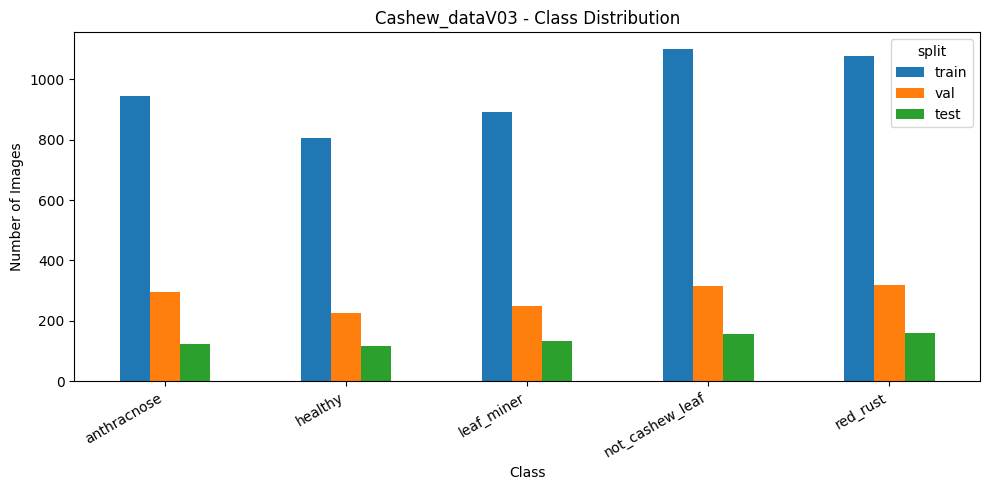

In [7]:

# ============================================================
# 07. DATASET DISTRIBUTION
# ============================================================

ax = stats_df[["train", "val", "test"]].plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("Cashew_dataV03 - Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    AGGREGATE_DIR / "class_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


In [8]:

# ============================================================
# 08. FIXED FILE LISTS + TF.DATA
# ============================================================

CLASS_NAMES = EXPECTED_CLASSES
NUM_CLASSES = len(CLASS_NAMES)
AUTOTUNE = tf.data.AUTOTUNE


def split_arrays(split_name):
    df = (
        valid_df[valid_df["split"] == split_name]
        .copy()
        .reset_index(drop=True)
    )

    return (
        df["path"].to_numpy(),
        df["label"].to_numpy(dtype=np.int32),
        df
    )


train_paths, train_labels, train_meta = split_arrays("train")
val_paths, val_labels, val_meta = split_arrays("val")
test_paths, test_labels, test_meta = split_arrays("test")


def decode_image(path, label):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE],
        method="bilinear"
    )

    return tf.cast(image, tf.float32), label


def make_dataset(paths, labels, seed, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        decode_image,
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    ds = ds.prefetch(AUTOTUNE)

    return ds


print("Fixed split:")
print("Train :", len(train_paths))
print("Val   :", len(val_paths))
print("Test  :", len(test_paths))

print("\nClass mapping:")
for idx, class_name in enumerate(CLASS_NAMES):
    print(f"{idx}: {class_name}")


Fixed split:
Train : 4822
Val   : 1402
Test  : 687

Class mapping:
0: anthracnose
1: healthy
2: leaf_miner
3: not_cashew_leaf
4: red_rust


# Vision Transformer Model Builder

Architecture:

```text
Input 224×224×3
→ mild augmentation
→ Rescaling(1/255)
→ Conv2D patch embedding (16×16, stride 16)
→ 196 patch tokens
→ learnable [CLS] token
→ learnable positional embedding
→ 8 Transformer Encoder blocks
→ final token normalization
→ CLS embedding
→ Dense(256, GELU)
→ Dropout(0.40)
→ Dense(5, Softmax)
```

Các custom layer dùng:

```python
@tf.keras.utils.register_keras_serializable(package="CashewViT")
```

để `.keras` có thể lưu/load ổn định. Notebook có **serialization smoke test trước training**.

In [9]:
# ============================================================
# 09. DATA AUGMENTATION + ViT MODEL BUILDER
# ============================================================

AUGMENTATION_CONFIG = {
    "horizontal_flip": True,
    "vertical_flip": False,
    "rotation_factor": 0.04,
    "zoom_factor": 0.05,
    "translation_factor": 0.03,
    "contrast_factor": 0.08,
    "brightness": False,
    "hue_shift": False,
}


def build_data_augmentation(seed):
    return keras.Sequential(
        [
            layers.RandomFlip("horizontal", seed=seed + 1),
            layers.RandomRotation(factor=0.04, seed=seed + 2),
            layers.RandomZoom(
                height_factor=(-0.05, 0.05),
                width_factor=(-0.05, 0.05),
                seed=seed + 3,
            ),
            layers.RandomTranslation(
                height_factor=0.03,
                width_factor=0.03,
                seed=seed + 4,
            ),
            layers.RandomContrast(factor=0.08, seed=seed + 5),
        ],
        name=f"data_augmentation_seed_{seed}"
    )


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ClassToken(layers.Layer):
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, int(input_shape[-1])),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        cls = tf.tile(self.cls_token, [batch_size, 1, 1])
        return tf.concat([cls, inputs], axis=1)


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class AddPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.projection_dim = int(projection_dim)

    def build(self, input_shape):
        self.position_embedding = self.add_weight(
            name="position_embedding",
            shape=(1, self.sequence_length, self.projection_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs + self.position_embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "projection_dim": self.projection_dim,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ExtractClassToken(layers.Layer):
    def call(self, inputs):
        return inputs[:, 0, :]


def transformer_mlp(x, block_index, seed):
    x = layers.Dense(
        TRANSFORMER_MLP_UNITS,
        activation="gelu",
        name=f"transformer_{block_index}_mlp_dense_1"
    )(x)
    x = layers.Dropout(
        TRANSFORMER_DROPOUT,
        seed=seed + 100 + block_index,
        name=f"transformer_{block_index}_mlp_dropout_1"
    )(x)
    x = layers.Dense(
        PROJECTION_DIM,
        name=f"transformer_{block_index}_mlp_dense_2"
    )(x)
    x = layers.Dropout(
        TRANSFORMER_DROPOUT,
        seed=seed + 200 + block_index,
        name=f"transformer_{block_index}_mlp_dropout_2"
    )(x)
    return x


def build_vit_model(seed):
    set_global_seed(seed)

    inputs = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3),
        name="image"
    )

    x = build_data_augmentation(seed)(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")(x)

    # Patch extraction + projection.
    x = layers.Conv2D(
        filters=PROJECTION_DIM,
        kernel_size=PATCH_SIZE,
        strides=PATCH_SIZE,
        padding="valid",
        name="patch_embedding_conv"
    )(x)

    x = layers.Reshape(
        (NUM_PATCHES, PROJECTION_DIM),
        name="patch_tokens"
    )(x)

    x = ClassToken(name="class_token")(x)
    x = AddPositionEmbedding(
        sequence_length=NUM_PATCHES + 1,
        projection_dim=PROJECTION_DIM,
        name="position_embedding"
    )(x)

    for block_index in range(TRANSFORMER_LAYERS):
        # Pre-LN attention
        x_norm = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_{block_index}_ln_1"
        )(x)

        attention = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM // NUM_HEADS,
            dropout=ATTENTION_DROPOUT,
            name=f"transformer_{block_index}_mha"
        )(x_norm, x_norm)

        attention = layers.Dropout(
            TRANSFORMER_DROPOUT,
            seed=seed + 300 + block_index,
            name=f"transformer_{block_index}_attention_dropout"
        )(attention)

        x = layers.Add(
            name=f"transformer_{block_index}_attention_residual"
        )([x, attention])

        # Pre-LN MLP
        x_norm = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"transformer_{block_index}_ln_2"
        )(x)

        mlp_output = transformer_mlp(
            x_norm,
            block_index=block_index,
            seed=seed
        )

        x = layers.Add(
            name=f"transformer_{block_index}_mlp_residual"
        )([x, mlp_output])

    token_features = layers.LayerNormalization(
        epsilon=1e-6,
        name="final_token_features"
    )(x)

    cls_embedding = ExtractClassToken(
        name="cls_embedding"
    )(token_features)

    x = layers.Dense(
        HEAD_UNITS,
        activation="gelu",
        name="classifier_dense"
    )(cls_embedding)

    x = layers.Dropout(
        HEAD_DROPOUT,
        seed=seed + 999,
        name="classifier_dropout"
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions"
    )(x)

    return keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"ViT_Scratch_seed_{seed}"
    )


print("Defined:")
print("- build_data_augmentation(seed)")
print("- ClassToken")
print("- AddPositionEmbedding")
print("- ExtractClassToken")
print("- build_vit_model(seed)")

Defined:
- build_data_augmentation(seed)
- ClassToken
- AddPositionEmbedding
- ExtractClassToken
- build_vit_model(seed)


In [10]:
# ============================================================
# 10. MODEL BUILDER SANITY CHECK + SERIALIZATION SMOKE TEST
# ============================================================

tf.keras.backend.clear_session()
gc.collect()

sanity_seed = SEEDS[0]

with strategy.scope():
    sanity_model = build_vit_model(sanity_seed)

assert sanity_model.output_shape == (None, NUM_CLASSES)

print("Model name       :", sanity_model.name)
print("Output shape     :", sanity_model.output_shape)
print("Total parameters :", sanity_model.count_params())
print("Patch tokens     :", NUM_PATCHES)
print("Sequence length  :", NUM_PATCHES + 1)

# Verify .keras serialization before hours of training.
smoke_path = OUT_DIR / "_vit_serialization_smoke_test.keras"
sanity_model.save(smoke_path)

loaded_model = keras.models.load_model(
    smoke_path,
    compile=False
)

assert loaded_model.output_shape == (None, NUM_CLASSES)
smoke_path.unlink(missing_ok=True)

print("\nSANITY CHECK PASSED.")
print("SERIALIZATION SMOKE TEST PASSED.")

del sanity_model
del loaded_model
tf.keras.backend.clear_session()
gc.collect()

Global seed set to: 42
Model name       : ViT_Scratch_seed_42
Output shape     : (None, 5)
Total parameters : 347717
Patch tokens     : 196
Sequence length  : 197

SANITY CHECK PASSED.
SERIALIZATION SMOKE TEST PASSED.


0

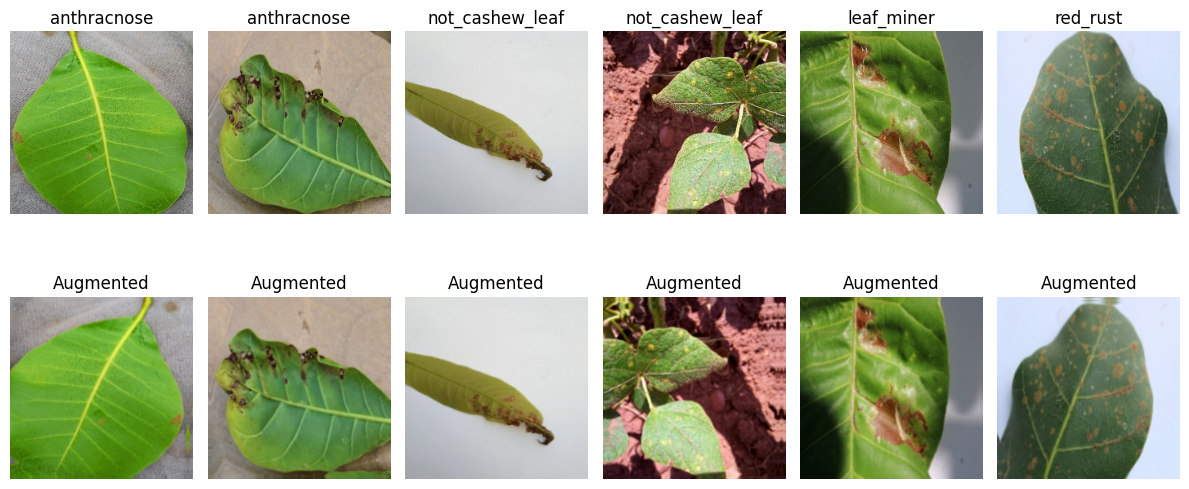

25301

In [11]:

# ============================================================
# 11. AUGMENTATION VISUAL CHECK
# ============================================================

preview_seed = SEEDS[0]

preview_ds = make_dataset(
    train_paths,
    train_labels,
    seed=preview_seed,
    training=True
)

preview_aug = build_data_augmentation(preview_seed)

for images, labels in preview_ds.take(1):

    n = min(6, int(images.shape[0]))

    plt.figure(figsize=(12, 6))

    for i in range(n):

        plt.subplot(2, 6, i + 1)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(images[i], 0, 255),
                tf.uint8
            )
        )
        plt.title(CLASS_NAMES[int(labels[i])])
        plt.axis("off")

        aug_img = preview_aug(
            tf.expand_dims(images[i], 0),
            training=True
        )[0]

        plt.subplot(2, 6, i + 7)
        plt.imshow(
            tf.cast(
                tf.clip_by_value(aug_img, 0, 255),
                tf.uint8
            )
        )
        plt.title("Augmented")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

del preview_ds, preview_aug
gc.collect()


In [12]:
# ============================================================
# 12. SAVE EXPERIMENT CONFIG
# ============================================================

experiment_config = {
    "experiment_id": EXPERIMENT_ID,
    "created_at": datetime.now().isoformat(),
    "dataset": {
        "version": DATASET_VERSION,
        "path": str(DATASET_PATH),
        "classes": CLASS_NAMES,
        "train_images": len(train_paths),
        "val_images": len(val_paths),
        "test_images": len(test_paths),
        "total_images": len(valid_df),
        "test_set_locked": True,
    },
    "model": {
        "name": MODEL_NAME,
        "training_mode": TRAINING_MODE,
        "pretrained_weights": PRETRAINED_WEIGHTS,
        "input_size": [IMG_SIZE, IMG_SIZE, 3],
        "patch_size": PATCH_SIZE,
        "num_patches": NUM_PATCHES,
        "sequence_length": NUM_PATCHES + 1,
        "projection_dim": PROJECTION_DIM,
        "num_heads": NUM_HEADS,
        "transformer_layers": TRANSFORMER_LAYERS,
        "transformer_mlp_units": TRANSFORMER_MLP_UNITS,
        "attention_dropout": ATTENTION_DROPOUT,
        "transformer_dropout": TRANSFORMER_DROPOUT,
        "head_units": HEAD_UNITS,
        "head_dropout": HEAD_DROPOUT,
    },
    "training": {
        "seeds": SEEDS,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "optimizer": "AdamW",
        "initial_learning_rate": INITIAL_LR,
        "weight_decay": WEIGHT_DECAY,
        "loss": "SparseCategoricalCrossentropy",
        "class_weight": None,
    },
    "augmentation": AUGMENTATION_CONFIG,
    "callbacks": {
        "checkpoint_monitor": "val_loss",
        "checkpoint_mode": "min",
        "checkpoint_type": "weights_only",
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "reduce_lr_patience": REDUCE_LR_PATIENCE,
        "reduce_lr_factor": REDUCE_LR_FACTOR,
        "min_lr": MIN_LR,
    },
    "test_protocol": {
        "run_final_test": RUN_FINAL_TEST,
        "final_test_completed": False,
        "same_locked_test_for_all_seeds": True,
        "do_not_select_best_seed_on_test": True,
        "summary": "mean ± sample standard deviation (ddof=1)",
    },
    "deployment_protocol": {
        "selection_source": "validation only",
        "selection_metric": "val_macro_f1",
        "tie_break": "lower val_loss",
        "test_used_for_deployment_seed_selection": False,
    },
    "archive": {
        "full_archive": f"{EXPERIMENT_ID}_FULL.zip",
        "analysis_archive": f"{EXPERIMENT_ID}_ANALYSIS.zip",
        "google_drive_target_url": DRIVE_TARGET_URL,
        "google_drive_target_folder_id": DRIVE_TARGET_FOLDER_ID,
    },
    "figure_protocol": {
        "seed_comparison_layout": "paper-style panel",
        "training_curves": "2 rows x 5 columns",
        "confusion_matrices": "1 row x 5 columns",
        "colormap": "Blues",
    },
    "hardware": {
        "gpu_count": len(gpus),
        "strategy": strategy.__class__.__name__,
        "replicas": strategy.num_replicas_in_sync,
    },
}

config_path = OUT_DIR / "experiment_config.json"
config_path.write_text(
    json.dumps(experiment_config, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

(OUT_DIR / "drive_target.json").write_text(
    json.dumps({
        "folder_url": DRIVE_TARGET_URL,
        "folder_id": DRIVE_TARGET_FOLDER_ID,
        "archive_to_upload": f"{EXPERIMENT_ID}_FULL.zip",
    }, indent=2),
    encoding="utf-8"
)

print("Saved:", config_path)

Saved: /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/experiment_config.json



# Train 5 Seeds

Cell tiếp theo chạy lần lượt:

```text
42 → 123 → 2026 → 3407 → 7777
```

Mỗi seed:
- tạo model mới hoàn toàn;
- train cùng một split;
- lưu `best.weights.h5` theo `val_loss`;
- lưu `history.csv`;
- lưu learning curves;
- sau train, **reload đúng best weights**;
- đánh giá Validation và lưu Macro-F1 / Balanced Accuracy / confusion matrix.

Test **không được đọc** trong cell này.


In [13]:

# ============================================================
# 13. TRAIN ALL 5 SEEDS
# ============================================================

training_rows = []
validation_rows = []

for run_index, seed in enumerate(SEEDS, start=1):

    print("\n" + "=" * 80)
    print(f"RUN {run_index}/{len(SEEDS)} - SEED {seed}")
    print("=" * 80)

    tf.keras.backend.clear_session()
    gc.collect()
    set_global_seed(seed)

    # --------------------------------------------------------
    # Folders
    # --------------------------------------------------------

    seed_dir = OUT_DIR / f"seed_{seed}"

    checkpoint_dir = seed_dir / "checkpoints"
    log_dir = seed_dir / "logs"
    figure_dir = seed_dir / "figures"
    validation_dir = seed_dir / "validation"

    for folder in [
        checkpoint_dir,
        log_dir,
        figure_dir,
        validation_dir,
    ]:
        folder.mkdir(parents=True, exist_ok=True)

    best_weights_path = (
        checkpoint_dir /
        f"VIT_SCRATCH_seed_{seed}_best.weights.h5"
    )

    # --------------------------------------------------------
    # Datasets
    # --------------------------------------------------------

    train_ds = make_dataset(
        train_paths,
        train_labels,
        seed=seed,
        training=True
    )

    val_ds = make_dataset(
        val_paths,
        val_labels,
        seed=seed,
        training=False
    )

    # --------------------------------------------------------
    # Build + compile
    # --------------------------------------------------------

    with strategy.scope():

        # CHỈ dùng function này.
        model = build_vit_model(seed)

        model.compile(
            optimizer=tf.keras.optimizers.AdamW(
                learning_rate=INITIAL_LR,
                weight_decay=WEIGHT_DECAY
            ),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"],
        )

    # --------------------------------------------------------
    # Model summary
    # --------------------------------------------------------

    summary_lines = []

    model.summary(
        print_fn=lambda line: summary_lines.append(line)
    )

    (
        seed_dir /
        "model_summary.txt"
    ).write_text(
        "\n".join(summary_lines),
        encoding="utf-8"
    )

    total_params = int(model.count_params())

    trainable_params = int(
        np.sum([
            np.prod(v.shape)
            for v in model.trainable_weights
        ])
    )

    non_trainable_params = int(
        total_params - trainable_params
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = [

        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(best_weights_path),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            save_weights_only=True,
            verbose=1,
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=REDUCE_LR_FACTOR,
            patience=REDUCE_LR_PATIENCE,
            min_lr=MIN_LR,
            verbose=1,
        ),

        tf.keras.callbacks.CSVLogger(
            str(log_dir / "training_log.csv")
        ),
    ]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    start_time = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    training_time_seconds = time.time() - start_time

    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    history_df = pd.DataFrame(history.history)

    history_df.insert(
        0,
        "epoch",
        np.arange(1, len(history_df) + 1)
    )

    history_df.to_csv(
        log_dir / "history.csv",
        index=False
    )

    actual_epochs = len(history_df)

    best_epoch = int(
        np.argmin(history.history["val_loss"])
    ) + 1

    best_val_loss_history = float(
        np.min(history.history["val_loss"])
    )

    best_val_accuracy_history = float(
        history.history["val_accuracy"][best_epoch - 1]
    )

    # --------------------------------------------------------
    # Curves
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["accuracy"],
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_accuracy"],
        label="Validation"
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label=f"Best epoch = {best_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Vision Transformer Scratch - Seed {seed} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        figure_dir / "accuracy_curve.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["loss"],
        label="Train"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        label="Validation"
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label=f"Best epoch = {best_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Vision Transformer Scratch - Seed {seed} - Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        figure_dir / "loss_curve.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # IMPORTANT:
    # Reload exactly the checkpoint chosen by minimum val_loss.
    # --------------------------------------------------------

    model.load_weights(best_weights_path)

    # --------------------------------------------------------
    # Validation evaluation
    # --------------------------------------------------------

    val_loss, val_accuracy = model.evaluate(
        val_ds,
        verbose=0
    )

    y_val_true = []
    y_val_prob = []

    for images, labels in val_ds:

        probs = model.predict(
            images,
            verbose=0
        )

        y_val_prob.append(probs)
        y_val_true.append(labels.numpy())

    y_val_true = np.concatenate(y_val_true)
    y_val_prob = np.concatenate(y_val_prob)
    y_val_pred = np.argmax(y_val_prob, axis=1)
    y_val_conf = np.max(y_val_prob, axis=1)

    val_metrics = {
        "seed": seed,
        "val_loss": float(val_loss),
        "val_accuracy": float(
            accuracy_score(y_val_true, y_val_pred)
        ),
        "val_macro_precision": float(
            precision_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_macro_recall": float(
            recall_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_macro_f1": float(
            f1_score(
                y_val_true,
                y_val_pred,
                average="macro",
                zero_division=0
            )
        ),
        "val_balanced_accuracy": float(
            balanced_accuracy_score(
                y_val_true,
                y_val_pred
            )
        ),
    }

    validation_rows.append(val_metrics)

    # --------------------------------------------------------
    # Validation classification report
    # --------------------------------------------------------

    val_report_df = pd.DataFrame(
        classification_report(
            y_val_true,
            y_val_pred,
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()

    val_report_df.to_csv(
        validation_dir /
        "classification_report.csv"
    )

    # --------------------------------------------------------
    # Validation confusion matrix
    # --------------------------------------------------------

    val_cm = confusion_matrix(
        y_val_true,
        y_val_pred
    )

    val_cm_norm = confusion_matrix(
        y_val_true,
        y_val_pred,
        normalize="true"
    )

    pd.DataFrame(
        val_cm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(
        validation_dir /
        "confusion_matrix.csv"
    )

    pd.DataFrame(
        val_cm_norm,
        index=CLASS_NAMES,
        columns=CLASS_NAMES
    ).to_csv(
        validation_dir /
        "confusion_matrix_normalized.csv"
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    ConfusionMatrixDisplay(
        confusion_matrix=val_cm,
        display_labels=CLASS_NAMES
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    plt.title(
        f"Validation Confusion Matrix - Seed {seed}"
    )

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    plt.savefig(
        validation_dir /
        "confusion_matrix.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    val_predictions_df = pd.DataFrame({
        "filename": val_meta["path"],
        "true_label": [
            CLASS_NAMES[int(i)]
            for i in y_val_true
        ],
        "predicted_label": [
            CLASS_NAMES[int(i)]
            for i in y_val_pred
        ],
        "confidence": y_val_conf,
        "correct": y_val_true == y_val_pred,
    })

    val_predictions_df.to_csv(
        validation_dir /
        "predictions.csv",
        index=False
    )

    # --------------------------------------------------------
    # Training summary
    # --------------------------------------------------------

    row = {
        "seed": seed,
        "actual_epochs": actual_epochs,
        "best_epoch": best_epoch,
        "best_val_loss_history": best_val_loss_history,
        "best_val_accuracy_history": best_val_accuracy_history,
        "checkpoint_val_loss": float(val_loss),
        "checkpoint_val_accuracy": float(val_metrics["val_accuracy"]),
        "checkpoint_val_macro_f1": float(val_metrics["val_macro_f1"]),
        "checkpoint_val_balanced_accuracy": float(
            val_metrics["val_balanced_accuracy"]
        ),
        "training_time_seconds": float(training_time_seconds),
        "total_parameters": total_params,
        "trainable_parameters": trainable_params,
        "non_trainable_parameters": non_trainable_params,
        "best_weights_path": str(best_weights_path),
        "best_weights_size_mb": float(
            best_weights_path.stat().st_size /
            (1024 ** 2)
        ),
    }

    training_rows.append(row)

    (
        seed_dir /
        "training_summary.json"
    ).write_text(
        json.dumps(
            row,
            indent=2
        ),
        encoding="utf-8"
    )

    print("\nSeed summary:")
    print(json.dumps(row, indent=2))

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model
    del train_ds
    del val_ds
    del history

    tf.keras.backend.clear_session()
    gc.collect()


training_summary_df = pd.DataFrame(training_rows)
validation_results_df = pd.DataFrame(validation_rows)

training_summary_df.to_csv(
    AGGREGATE_DIR /
    "training_summary_5seeds.csv",
    index=False
)

validation_results_df.to_csv(
    AGGREGATE_DIR /
    "validation_results_5seeds.csv",
    index=False
)

print("\nTraining summary:")
display(training_summary_df)

print("\nValidation metrics:")
display(validation_results_df)



RUN 1/5 - SEED 42
Global seed set to: 42
Global seed set to: 42


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

2026-09-21 18:11:41.281452: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Seed summary:
{
  "seed": 42,
  "actual_epochs": 30,
  "best_epoch": 20,
  "best_val_loss_history": 0.487936407327652,
  "best_val_accuracy_history": 0.835948646068573,
  "checkpoint_val_loss": 0.487936407327652,
  "checkpoint_val_accuracy": 0.8359486447931527,
  "checkpoint_val_macro_f1": 0.8296809294529922,
  "checkpoint_val_balanced_accuracy": 0.8233999186442029,
  "training_time_seconds": 692.0204129219055,
  "total_parameters": 347717,
  "trainable_parameters": 347717,
  "non_trainable_parameters": 0,
  "best_weights_path": "/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/seed_42/checkpoints/VIT_SCRATCH_seed_42_best.weights.h5",
  "best_weights_size_mb": 4.413238525390625
}

RUN 2/5 - SEED 123
Global seed set to: 123
Global seed set to: 123


Epoch 1/60
INFO:tensorflow:Collective all_reduce tensors: 138 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5048 - loss: 1.1596
Epoch 3: val_loss did not improve from 1.17122
151/151 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.5207 - loss: 1.1354 - val_accuracy: 0.4351 - val_loss: 1.2507 - learning_rate: 3.0000e-04
Epoch 4/60
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5745 - loss: 1.0137
Epoch 4: val_loss improved from 1.17122 to 1.16491, saving model to /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/seed_123/checkpoints/VIT_SCRATCH_seed_123_best.weights.h5

Epoch 4: finished saving model to /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/seed_123/checkpoints/VIT_SCRATCH_seed_123_best.weights.h5
151/151 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.5906 - loss: 0.9916 - val_accuracy: 0.4850 - val_loss: 1.1649 - learning_rate: 3.0000e-04
Epoch 5/60
151

...

2026-09-21 19:14:05.453083: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



Seed summary:
{
  "seed": 7777,
  "actual_epochs": 38,
  "best_epoch": 28,
  "best_val_loss_history": 0.4129214584827423,
  "best_val_accuracy_history": 0.8687589168548584,
  "checkpoint_val_loss": 0.4129214584827423,
  "checkpoint_val_accuracy": 0.8687589158345221,
  "checkpoint_val_macro_f1": 0.8654314176024223,
  "checkpoint_val_balanced_accuracy": 0.8671359586706808,
  "training_time_seconds": 857.5433330535889,
  "total_parameters": 347717,
  "trainable_parameters": 347717,
  "non_trainable_parameters": 0,
  "best_weights_path": "/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/seed_7777/checkpoints/VIT_SCRATCH_seed_7777_best.weights.h5",
  "best_weights_size_mb": 4.413238525390625
}

Training summary:


,seed,actual_epochs,best_epoch,best_val_loss_history,best_val_accuracy_history,checkpoint_val_loss,checkpoint_val_accuracy,checkpoint_val_macro_f1,checkpoint_val_balanced_accuracy,training_time_seconds,total_parameters,trainable_parameters,non_trainable_parameters,best_weights_path,best_weights_size_mb
0,42,30,20,0.487936,0.835949,0.487936,0.835949,0.829681,0.823400,692.020413,347717,347717,0,/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/see...,4.413239
1,123,42,32,0.403401,0.860200,0.403401,0.860200,0.854047,0.851863,949.718769,347717,347717,0,/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/see...,4.413239
2,2026,35,25,0.457196,0.853780,0.457196,0.853780,0.846329,0.845267,809.651423,347717,347717,0,/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/see...,4.413239
3,3407,45,35,0.434307,0.845221,0.434307,0.845221,0.838554,0.835142,998.983255,347717,347717,0,/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/see...,4.413239
4,7777,38,28,0.412921,0.868759,0.412921,0.868759,0.865431,0.867136,857.543333,347717,347717,0,/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/see...,4.413239



Validation metrics:


,seed,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_balanced_accuracy
0,42,0.487936,0.835949,0.843886,0.823400,0.829681,0.823400
1,123,0.403401,0.860200,0.857753,0.851863,0.854047,0.851863
2,2026,0.457196,0.853780,0.848643,0.845267,0.846329,0.845267
3,3407,0.434307,0.845221,0.845121,0.835142,0.838554,0.835142
4,7777,0.412921,0.868759,0.864413,0.867136,0.865431,0.867136


In [14]:

# ============================================================
# 14. VALIDATION MEAN ± STD
# ============================================================

validation_metrics_to_summarize = [
    "val_accuracy",
    "val_macro_precision",
    "val_macro_recall",
    "val_macro_f1",
    "val_balanced_accuracy",
]

validation_summary_rows = []

for metric in validation_metrics_to_summarize:

    values = validation_results_df[metric]

    validation_summary_rows.append({
        "metric": metric,
        "mean": float(values.mean()),
        "std": float(values.std(ddof=1)),
        "report": (
            f"{values.mean()*100:.2f} ± "
            f"{values.std(ddof=1)*100:.2f}%"
        ),
    })

validation_mean_std_df = pd.DataFrame(
    validation_summary_rows
)

display(validation_mean_std_df)

validation_mean_std_df.to_csv(
    AGGREGATE_DIR /
    "validation_mean_std_summary.csv",
    index=False
)

print("\nBest epoch across seeds:")
print(
    f"{training_summary_df['best_epoch'].mean():.2f} ± "
    f"{training_summary_df['best_epoch'].std(ddof=1):.2f}"
)


,metric,mean,std,report
0,val_accuracy,0.852782,0.012765,85.28 ± 1.28%
1,val_macro_precision,0.851963,0.008826,85.20 ± 0.88%
2,val_macro_recall,0.844562,0.016583,84.46 ± 1.66%
3,val_macro_f1,0.846808,0.013793,84.68 ± 1.38%
4,val_balanced_accuracy,0.844562,0.016583,84.46 ± 1.66%



Best epoch across seeds:
28.00 ± 5.87


Created: /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/figures/panels/training_curves_5seeds_panel.png
Created: /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/figures/panels/validation_confusion_matrices_5seeds_panel.png


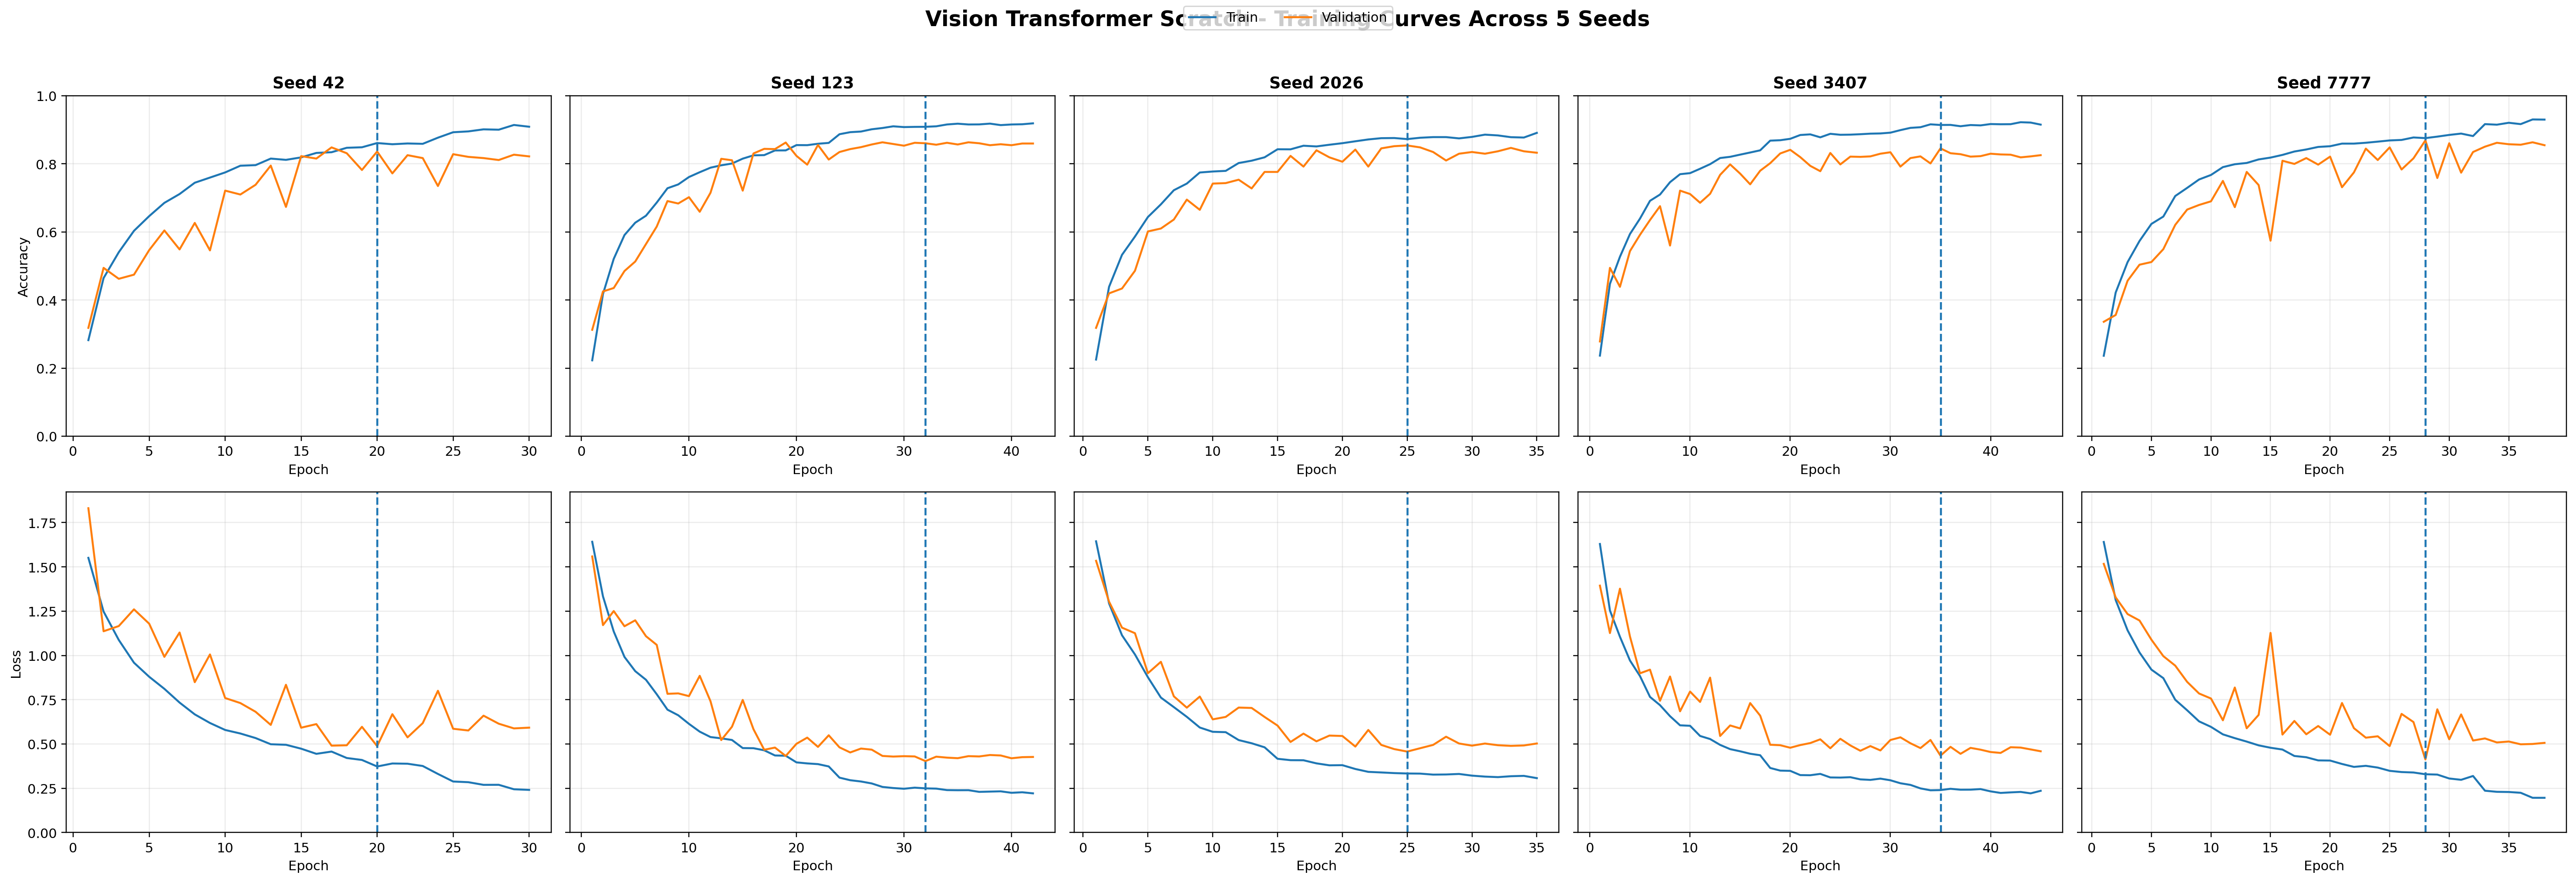

In [15]:
# ============================================================
# 14B. PAPER-STYLE 5-SEED VALIDATION PANELS
# ============================================================

# A. Training curves — 2 rows x 5 seed columns
histories = {}
for seed in SEEDS:
    history_path = OUT_DIR / f"seed_{seed}" / "logs" / "history.csv"
    histories[seed] = pd.read_csv(history_path)

fig, axes = plt.subplots(
    2,
    len(SEEDS),
    figsize=(27, 9),
    sharey="row"
)

all_losses = []
for seed in SEEDS:
    all_losses.extend(histories[seed]["loss"].tolist())
    all_losses.extend(histories[seed]["val_loss"].tolist())

loss_upper = max(all_losses) * 1.05

for col, seed in enumerate(SEEDS):
    hist = histories[seed]
    best_epoch = int(hist.loc[hist["val_loss"].idxmin(), "epoch"])

    axes[0, col].plot(hist["epoch"], hist["accuracy"], label="Train")
    axes[0, col].plot(hist["epoch"], hist["val_accuracy"], label="Validation")
    axes[0, col].axvline(best_epoch, linestyle="--")
    axes[0, col].set_title(f"Seed {seed}", fontweight="bold")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].set_ylim(0, 1)
    axes[0, col].grid(alpha=0.25)

    axes[1, col].plot(hist["epoch"], hist["loss"], label="Train")
    axes[1, col].plot(hist["epoch"], hist["val_loss"], label="Validation")
    axes[1, col].axvline(best_epoch, linestyle="--")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].set_ylim(0, loss_upper)
    axes[1, col].grid(alpha=0.25)

axes[0, 0].set_ylabel("Accuracy")
axes[1, 0].set_ylabel("Loss")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle(
    "Vision Transformer Scratch - Training Curves Across 5 Seeds",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)
fig.tight_layout()

training_panel_path = PANEL_DIR / "training_curves_5seeds_panel.png"
fig.savefig(training_panel_path, dpi=220, bbox_inches="tight")
plt.close(fig)

# B. Normalized Validation confusion matrices — 1 x 5
fig, axes = plt.subplots(
    1,
    len(SEEDS),
    figsize=(30, 6.5),
    constrained_layout=True
)

last_im = None

for col, seed in enumerate(SEEDS):
    cm_path = (
        OUT_DIR / f"seed_{seed}" / "validation" /
        "confusion_matrix_normalized.csv"
    )
    cm = pd.read_csv(cm_path, index_col=0).to_numpy()
    ax = axes[col]

    last_im = ax.imshow(
        cm,
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
        aspect="equal"
    )

    ax.set_title(f"Seed {seed}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)

    if col == 0:
        ax.set_yticklabels(CLASS_NAMES, fontsize=9)
        ax.set_ylabel("True label", fontsize=11)
    else:
        ax.set_yticklabels([])

    ax.set_xlabel("Predicted label", fontsize=10)

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            value = float(cm[i, j])
            text_color = "white" if value >= 0.55 else "black"
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

cbar = fig.colorbar(last_im, ax=axes, fraction=0.018, pad=0.015)
cbar.set_label("Row-normalized proportion", fontsize=10)

fig.suptitle(
    "Vision Transformer Scratch - Validation Normalized Confusion Matrices Across 5 Seeds",
    fontsize=16,
    fontweight="bold"
)

validation_panel_path = PANEL_DIR / "validation_confusion_matrices_5seeds_panel.png"
fig.savefig(validation_panel_path, dpi=220, bbox_inches="tight")
plt.close(fig)

print("Created:", training_panel_path)
print("Created:", validation_panel_path)
display(Image.open(training_panel_path))


# FINAL TEST GATE

**Dừng ở đây nếu bạn chưa muốn mở Test Set.**

Sau khi 5 seeds đã train xong và bạn xác nhận cấu hình không thay đổi nữa:

1. quay lại Cell `03. CONFIGURATION`;
2. đổi:

```python
RUN_FINAL_TEST = True
```

3. chạy lại Cell 03;
4. **không chạy lại Cell Train**;
5. chạy từ cell `15. FINAL TEST` trở xuống.

Final Test sẽ build lại đúng architecture cho từng seed, load `best.weights.h5`, rồi đánh giá cùng một Test Set đã khóa.


In [16]:

# ============================================================
# 15. FINAL TEST - 5 SEEDS
# ============================================================

test_result_rows = []

if not RUN_FINAL_TEST:

    print(
        "FINAL TEST IS LOCKED.\n"
        "RUN_FINAL_TEST = False\n"
        "Không đánh giá Test trong lần chạy này."
    )

else:

    test_ds = make_dataset(
        test_paths,
        test_labels,
        seed=SEEDS[0],
        training=False
    )

    for run_index, seed in enumerate(SEEDS, start=1):

        print("\n" + "=" * 80)
        print(
            f"FINAL TEST {run_index}/{len(SEEDS)} - SEED {seed}"
        )
        print("=" * 80)

        tf.keras.backend.clear_session()
        gc.collect()
        set_global_seed(seed)

        seed_dir = OUT_DIR / f"seed_{seed}"

        best_weights_path = (
            seed_dir /
            "checkpoints" /
            f"VIT_SCRATCH_seed_{seed}_best.weights.h5"
        )

        if not best_weights_path.exists():
            raise FileNotFoundError(
                f"Missing checkpoint: {best_weights_path}"
            )

        metric_dir = seed_dir / "test_metrics"
        figure_dir = seed_dir / "test_figures"
        prediction_dir = seed_dir / "test_predictions"
        error_dir = prediction_dir / "error_cases"

        for folder in [
            metric_dir,
            figure_dir,
            prediction_dir,
            error_dir,
        ]:
            folder.mkdir(
                parents=True,
                exist_ok=True
            )

        # ----------------------------------------------------
        # Rebuild exact architecture and load best weights
        # ----------------------------------------------------

        with strategy.scope():

            model = build_vit_model(seed)

            # Load weights BEFORE compile so Final Test does not
            # attempt to restore stale optimizer variables.
            model.load_weights(
                best_weights_path
            )

            model.compile(
                optimizer=tf.keras.optimizers.AdamW(
                    learning_rate=INITIAL_LR,
                    weight_decay=WEIGHT_DECAY
                ),
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=["accuracy"],
            )

        # ----------------------------------------------------
        # Evaluate
        # ----------------------------------------------------

        test_loss, test_accuracy_keras = model.evaluate(
            test_ds,
            verbose=0
        )

        # Warm-up bằng nguyên batch đầu tiên.
        # Không dùng batch=1 khi MirroredStrategy có nhiều GPU.
        _ = model.predict(
            test_ds.take(1),
            verbose=0
        )

        prediction_start = time.perf_counter()

        # Predict toàn bộ Test Dataset trong một call để giảm overhead
        # và cho phép MirroredStrategy tự phân phối batch ổn định.
        y_prob = model.predict(
            test_ds,
            verbose=0
        )

        prediction_time = (
            time.perf_counter() -
            prediction_start
        )

        # Test dataset không shuffle nên thứ tự prediction
        # trùng với test_labels.
        y_true = np.asarray(
            test_labels,
            dtype=np.int32
        )

        y_pred = np.argmax(
            y_prob,
            axis=1
        )

        confidences = np.max(
            y_prob,
            axis=1
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        macro_precision = precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_recall = recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        macro_f1 = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )

        balanced_acc = balanced_accuracy_score(
            y_true,
            y_pred
        )

        weighted_precision = precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        weighted_recall = recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )

        inference_ms = (
            prediction_time /
            len(y_true)
        ) * 1000.0

        fps = (
            len(y_true) /
            prediction_time
        )

        # ----------------------------------------------------
        # Reports
        # ----------------------------------------------------

        report_df = pd.DataFrame(
            classification_report(
                y_true,
                y_pred,
                target_names=CLASS_NAMES,
                output_dict=True,
                zero_division=0,
            )
        ).transpose()

        report_df.to_csv(
            metric_dir /
            "classification_report.csv"
        )

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        cm_norm = confusion_matrix(
            y_true,
            y_pred,
            normalize="true"
        )

        pd.DataFrame(
            cm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        ).to_csv(
            metric_dir /
            "confusion_matrix.csv"
        )

        pd.DataFrame(
            cm_norm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        ).to_csv(
            metric_dir /
            "confusion_matrix_normalized.csv"
        )

        # ----------------------------------------------------
        # Confusion matrix figures
        # ----------------------------------------------------

        fig, ax = plt.subplots(figsize=(8, 7))

        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        ).plot(
            ax=ax,
            cmap="Blues",
            values_format="d",
            colorbar=False
        )

        plt.title(
            f"Test Confusion Matrix - Seed {seed}"
        )

        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        plt.savefig(
            figure_dir /
            "confusion_matrix.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close()

        fig, ax = plt.subplots(figsize=(8, 7))

        ConfusionMatrixDisplay(
            confusion_matrix=cm_norm,
            display_labels=CLASS_NAMES
        ).plot(
            ax=ax,
            cmap="Blues",
            values_format=".2f",
            colorbar=False
        )

        plt.title(
            f"Normalized Test Confusion Matrix - Seed {seed}"
        )

        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()

        plt.savefig(
            figure_dir /
            "confusion_matrix_normalized.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close()

        # ----------------------------------------------------
        # Prediction CSV
        # ----------------------------------------------------

        predictions_df = pd.DataFrame({
            "filename": test_meta["path"],
            "true_label": [
                CLASS_NAMES[int(i)]
                for i in y_true
            ],
            "predicted_label": [
                CLASS_NAMES[int(i)]
                for i in y_pred
            ],
            "confidence": confidences,
            "correct": y_true == y_pred,
        })

        predictions_df.to_csv(
            prediction_dir /
            "predictions.csv",
            index=False
        )

        wrong_df = (
            predictions_df[
                ~predictions_df["correct"]
            ]
            .sort_values(
                "confidence",
                ascending=False
            )
        )

        wrong_df.head(20).to_csv(
            error_dir /
            "highest_confidence_wrong.csv",
            index=False
        )

        correct_low_conf = (
            predictions_df[
                predictions_df["correct"]
            ]
            .sort_values(
                "confidence",
                ascending=True
            )
        )

        correct_low_conf.head(20).to_csv(
            error_dir /
            "lowest_confidence_correct.csv",
            index=False
        )

        # ----------------------------------------------------
        # Seed metrics
        # ----------------------------------------------------

        seed_metrics = {
            "seed": seed,
            "test_loss": float(test_loss),
            "accuracy": float(accuracy),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
            "balanced_accuracy": float(balanced_acc),
            "weighted_precision": float(weighted_precision),
            "weighted_recall": float(weighted_recall),
            "weighted_f1": float(weighted_f1),
            "weights_size_mb": float(
                best_weights_path.stat().st_size /
                (1024 ** 2)
            ),
            "inference_time_ms_per_image": float(inference_ms),
            "fps": float(fps),
        }

        (
            metric_dir /
            "metrics.json"
        ).write_text(
            json.dumps(
                seed_metrics,
                indent=2
            ),
            encoding="utf-8"
        )

        test_result_rows.append(
            seed_metrics
        )

        print(json.dumps(seed_metrics, indent=2))

        del model
        tf.keras.backend.clear_session()
        gc.collect()


    test_results_df = pd.DataFrame(
        test_result_rows
    )

    test_results_df.to_csv(
        AGGREGATE_DIR /
        "aggregate_test_results.csv",
        index=False
    )

    display(test_results_df)



FINAL TEST 1/5 - SEED 42
Global seed set to: 42
Global seed set to: 42
{
  "seed": 42,
  "test_loss": 0.4593236744403839,
  "accuracy": 0.8355167394468704,
  "macro_precision": 0.8382334253710271,
  "macro_recall": 0.826431499979579,
  "macro_f1": 0.8287187102177016,
  "balanced_accuracy": 0.826431499979579,
  "weighted_precision": 0.8519625969445513,
  "weighted_recall": 0.8355167394468704,
  "weighted_f1": 0.8403620367580168,
  "weights_size_mb": 4.413238525390625,
  "inference_time_ms_per_image": 6.017759475983358,
  "fps": 166.17480376059572
}

FINAL TEST 2/5 - SEED 123
Global seed set to: 123
Global seed set to: 123
{
  "seed": 123,
  "test_loss": 0.39986568689346313,
  "accuracy": 0.8617176128093159,
  "macro_precision": 0.8565254280257465,
  "macro_recall": 0.8559654910452039,
  "macro_f1": 0.8538972761216759,
  "balanced_accuracy": 0.8559654910452039,
  "weighted_precision": 0.8676846601618377,
  "weighted_recall": 0.8617176128093159,
  "weighted_f1": 0.862588196554806,
  "wei

,seed,test_loss,accuracy,macro_precision,macro_recall,macro_f1,balanced_accuracy,weighted_precision,weighted_recall,weighted_f1,weights_size_mb,inference_time_ms_per_image,fps
0,42,0.459324,0.835517,0.838233,0.826431,0.828719,0.826431,0.851963,0.835517,0.840362,4.413239,6.017759,166.174804
1,123,0.399866,0.861718,0.856525,0.855965,0.853897,0.855965,0.867685,0.861718,0.862588,4.413239,6.105865,163.776959
2,2026,0.353578,0.867540,0.861741,0.859708,0.857864,0.859708,0.872714,0.867540,0.867626,4.413239,6.171086,162.046026
3,3407,0.382434,0.866084,0.860614,0.860696,0.857556,0.860696,0.871144,0.866084,0.865880,4.413239,5.932951,168.550176
4,7777,0.455098,0.834061,0.834755,0.829770,0.822497,0.829770,0.849619,0.834061,0.832667,4.413239,6.183482,161.721188


In [17]:

# ============================================================
# 16. TEST MEAN ± STD + THESIS TABLE
# ============================================================

if not RUN_FINAL_TEST:

    print(
        "Skipped: Final Test chưa chạy."
    )

else:

    summary_metrics = [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "balanced_accuracy",
        "weighted_f1",
        "inference_time_ms_per_image",
        "fps",
    ]

    summary_rows = []

    for metric in summary_metrics:

        values = test_results_df[metric]

        summary_rows.append({
            "metric": metric,
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
            "report": (
                f"{values.mean():.6f} ± "
                f"{values.std(ddof=1):.6f}"
            ),
        })

    mean_std_df = pd.DataFrame(
        summary_rows
    )

    display(mean_std_df)

    mean_std_df.to_csv(
        AGGREGATE_DIR /
        "test_mean_std_summary.csv",
        index=False
    )

    thesis_metrics = [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "balanced_accuracy",
        "weighted_f1",
    ]

    thesis_rows = []

    for metric in thesis_metrics:

        values = (
            test_results_df[metric]
            * 100
        )

        thesis_rows.append({
            "Metric": metric,
            "Mean (%)": float(values.mean()),
            "Std (%)": float(values.std(ddof=1)),
            "Report": (
                f"{values.mean():.2f} ± "
                f"{values.std(ddof=1):.2f}%"
            ),
        })

    thesis_summary_df = pd.DataFrame(
        thesis_rows
    )

    print("\nThesis-ready table:")
    display(thesis_summary_df)

    thesis_summary_df.to_csv(
        AGGREGATE_DIR /
        "thesis_test_mean_std_summary.csv",
        index=False
    )

    aggregate_metrics = {
        "experiment_id": EXPERIMENT_ID,
        "model": MODEL_NAME,
        "training_mode": TRAINING_MODE,
        "dataset": DATASET_VERSION,
        "seeds": SEEDS,
        "num_seeds": len(SEEDS),
        "std_definition": "sample standard deviation (ddof=1)",
        "test_set_locked": True,
        "per_seed_results": test_result_rows,
        "summary": {
            row["metric"]: {
                "mean": float(row["mean"]),
                "std": float(row["std"]),
            }
            for row in summary_rows
        },
    }

    (
        AGGREGATE_DIR /
        "aggregate_test_metrics.json"
    ).write_text(
        json.dumps(
            aggregate_metrics,
            indent=2
        ),
        encoding="utf-8"
    )


,metric,mean,std,report
0,accuracy,0.852984,0.016755,0.852984 ± 0.016755
1,macro_precision,0.850374,0.012877,0.850374 ± 0.012877
2,macro_recall,0.846514,0.016943,0.846514 ± 0.016943
3,macro_f1,0.844107,0.017101,0.844107 ± 0.017101
4,balanced_accuracy,0.846514,0.016943,0.846514 ± 0.016943
5,weighted_f1,0.853825,0.016136,0.853825 ± 0.016136
6,inference_time_ms_per_image,6.082229,0.106239,6.082229 ± 0.106239
7,fps,164.453831,2.892439,164.453831 ± 2.892439



Thesis-ready table:


,Metric,Mean (%),Std (%),Report
0,accuracy,85.298399,1.675526,85.30 ± 1.68%
1,macro_precision,85.037362,1.287670,85.04 ± 1.29%
2,macro_recall,84.651425,1.694272,84.65 ± 1.69%
3,macro_f1,84.410672,1.710113,84.41 ± 1.71%
4,balanced_accuracy,84.651425,1.694272,84.65 ± 1.69%
5,weighted_f1,85.382451,1.613594,85.38 ± 1.61%


In [18]:

# ============================================================
# 17. PER-CLASS MEAN ± STD ACROSS 5 SEEDS
# ============================================================

if not RUN_FINAL_TEST:

    print(
        "Skipped: Final Test chưa chạy."
    )

else:

    per_class_rows = []

    for class_name in CLASS_NAMES:

        precision_values = []
        recall_values = []
        f1_values = []

        for seed in SEEDS:

            report_path = (
                OUT_DIR /
                f"seed_{seed}" /
                "test_metrics" /
                "classification_report.csv"
            )

            report_df = pd.read_csv(
                report_path,
                index_col=0
            )

            precision_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "precision"
                    ]
                )
            )

            recall_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "recall"
                    ]
                )
            )

            f1_values.append(
                float(
                    report_df.loc[
                        class_name,
                        "f1-score"
                    ]
                )
            )

        per_class_rows.append({
            "class": class_name,
            "precision_mean": np.mean(precision_values),
            "precision_std": np.std(precision_values, ddof=1),
            "recall_mean": np.mean(recall_values),
            "recall_std": np.std(recall_values, ddof=1),
            "f1_mean": np.mean(f1_values),
            "f1_std": np.std(f1_values, ddof=1),
            "f1_report": (
                f"{np.mean(f1_values)*100:.2f} ± "
                f"{np.std(f1_values, ddof=1)*100:.2f}%"
            ),
        })

    per_class_summary_df = pd.DataFrame(
        per_class_rows
    )

    display(per_class_summary_df)

    per_class_summary_df.to_csv(
        AGGREGATE_DIR /
        "per_class_test_mean_std.csv",
        index=False
    )


,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,f1_report
0,anthracnose,0.744060,0.086091,0.678689,0.071786,0.704338,0.044391,70.43 ± 4.44%
1,healthy,0.731298,0.023252,0.881356,0.075562,0.797166,0.022205,79.72 ± 2.22%
2,leaf_miner,0.851803,0.067549,0.850000,0.046515,0.848126,0.024459,84.81 ± 2.45%
3,not_cashew_leaf,0.986923,0.010440,0.959236,0.021880,0.972788,0.013659,97.28 ± 1.37%
4,red_rust,0.937783,0.020246,0.863291,0.044664,0.898116,0.019017,89.81 ± 1.90%


Created: /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/figures/panels/test_confusion_matrices_5seeds_panel.png
Created: /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/figures/panels/test_confusion_matrices_normalized_5seeds_panel.png


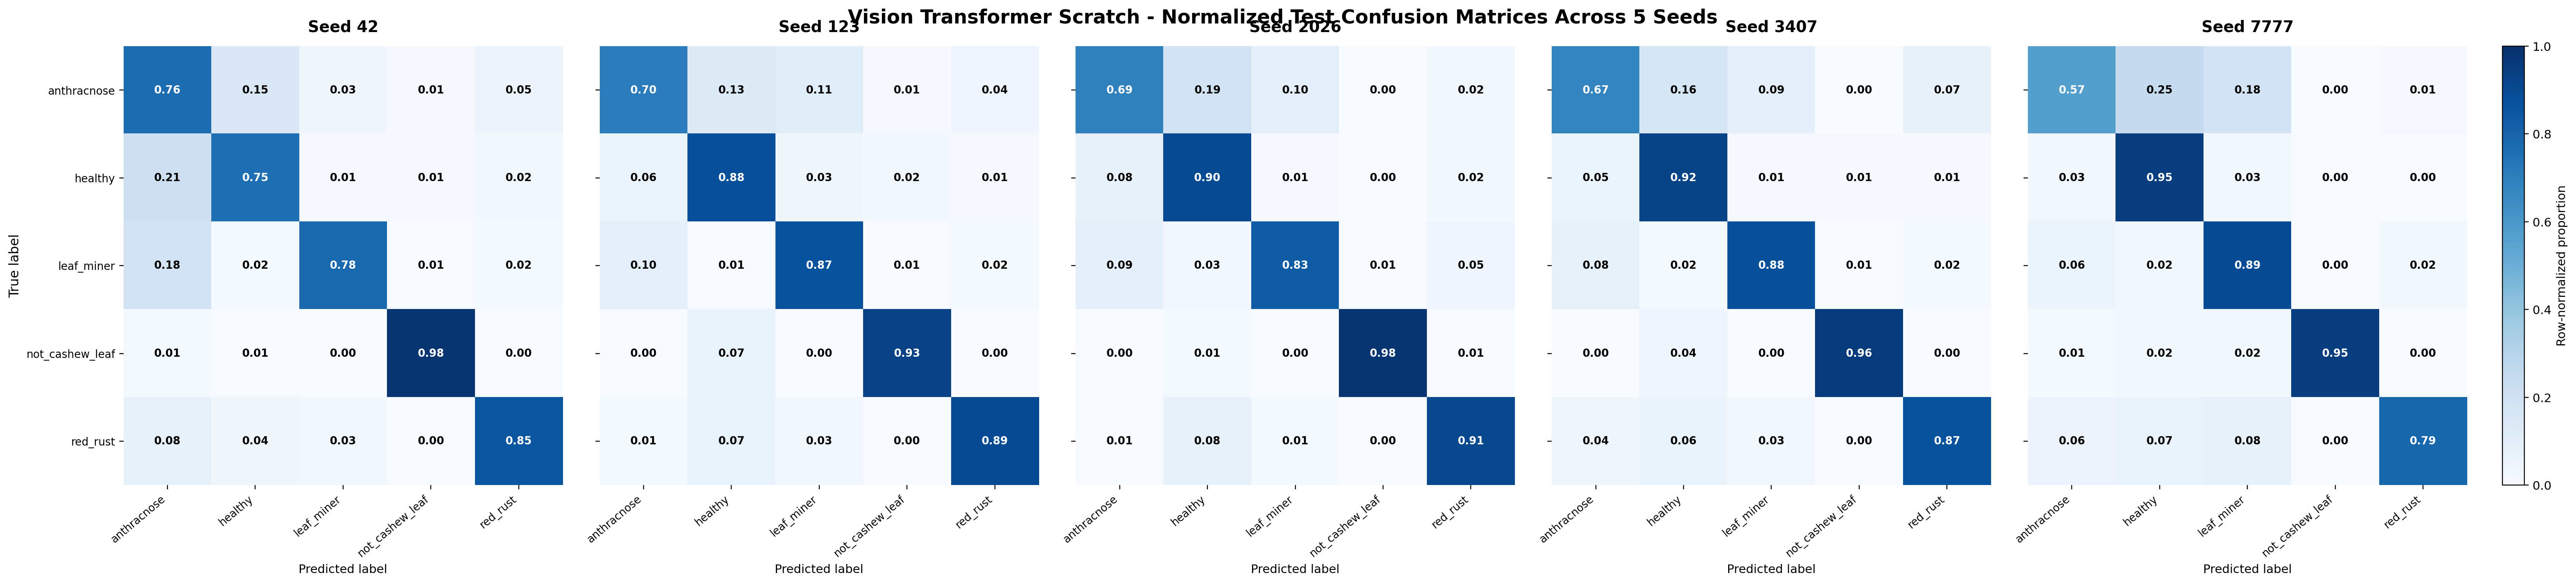

Updated experiment_config.json: final_test_completed = True


In [19]:
# ============================================================
# 17B. PAPER-STYLE TEST CONFUSION MATRIX PANELS
# ============================================================

if not RUN_FINAL_TEST:
    print("Skipped: Final Test chưa chạy.")
else:
    raw_cms = {}
    normalized_cms = {}

    for seed in SEEDS:
        raw_path = OUT_DIR / f"seed_{seed}" / "test_metrics" / "confusion_matrix.csv"
        norm_path = OUT_DIR / f"seed_{seed}" / "test_metrics" / "confusion_matrix_normalized.csv"
        raw_cms[seed] = pd.read_csv(raw_path, index_col=0).to_numpy()
        normalized_cms[seed] = pd.read_csv(norm_path, index_col=0).to_numpy()

    # Raw matrices
    raw_vmax = max(np.max(raw_cms[seed]) for seed in SEEDS)
    fig, axes = plt.subplots(
        1,
        len(SEEDS),
        figsize=(30, 6.5),
        constrained_layout=True
    )

    last_im = None

    for col, seed in enumerate(SEEDS):
        cm = raw_cms[seed]
        ax = axes[col]
        last_im = ax.imshow(
            cm,
            cmap="Blues",
            vmin=0,
            vmax=raw_vmax,
            aspect="equal"
        )
        ax.set_title(f"Seed {seed}", fontsize=13, fontweight="bold", pad=12)
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
        if col == 0:
            ax.set_yticklabels(CLASS_NAMES, fontsize=9)
            ax.set_ylabel("True label", fontsize=11)
        else:
            ax.set_yticklabels([])
        ax.set_xlabel("Predicted label", fontsize=10)

        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                value = int(cm[i, j])
                color = "white" if value >= raw_vmax * 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{value}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=color
                )

        for spine in ax.spines.values():
            spine.set_visible(False)

    cbar = fig.colorbar(last_im, ax=axes, fraction=0.018, pad=0.015)
    cbar.set_label("Number of images", fontsize=10)
    fig.suptitle(
        "Vision Transformer Scratch - Test Confusion Matrices Across 5 Seeds",
        fontsize=16,
        fontweight="bold"
    )

    raw_panel = PANEL_DIR / "test_confusion_matrices_5seeds_panel.png"
    fig.savefig(raw_panel, dpi=220, bbox_inches="tight")
    plt.close(fig)

    # Normalized matrices
    fig, axes = plt.subplots(
        1,
        len(SEEDS),
        figsize=(30, 6.5),
        constrained_layout=True
    )

    last_im = None

    for col, seed in enumerate(SEEDS):
        cm = normalized_cms[seed]
        ax = axes[col]
        last_im = ax.imshow(
            cm,
            cmap="Blues",
            vmin=0.0,
            vmax=1.0,
            aspect="equal"
        )
        ax.set_title(f"Seed {seed}", fontsize=13, fontweight="bold", pad=12)
        ax.set_xticks(range(NUM_CLASSES))
        ax.set_yticks(range(NUM_CLASSES))
        ax.set_xticklabels(CLASS_NAMES, rotation=40, ha="right", fontsize=9)
        if col == 0:
            ax.set_yticklabels(CLASS_NAMES, fontsize=9)
            ax.set_ylabel("True label", fontsize=11)
        else:
            ax.set_yticklabels([])
        ax.set_xlabel("Predicted label", fontsize=10)

        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                value = float(cm[i, j])
                color = "white" if value >= 0.55 else "black"
                ax.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=color
                )

        for spine in ax.spines.values():
            spine.set_visible(False)

    cbar = fig.colorbar(last_im, ax=axes, fraction=0.018, pad=0.015)
    cbar.set_label("Row-normalized proportion", fontsize=10)
    fig.suptitle(
        "Vision Transformer Scratch - Normalized Test Confusion Matrices Across 5 Seeds",
        fontsize=16,
        fontweight="bold"
    )

    normalized_panel = PANEL_DIR / "test_confusion_matrices_normalized_5seeds_panel.png"
    fig.savefig(normalized_panel, dpi=220, bbox_inches="tight")
    plt.close(fig)

    print("Created:", raw_panel)
    print("Created:", normalized_panel)
    display(Image.open(normalized_panel))

    # Update metadata only after successful Final Test.
    _cfg = json.loads(config_path.read_text(encoding="utf-8"))
    _cfg.setdefault("test_protocol", {})["run_final_test"] = True
    _cfg["test_protocol"]["final_test_completed"] = True
    config_path.write_text(
        json.dumps(_cfg, indent=2, ensure_ascii=False),
        encoding="utf-8"
    )
    print("Updated experiment_config.json: final_test_completed = True")

# Deployment package for later YOLO integration

Deployment seed được chọn **chỉ bằng Validation**:

```text
highest Validation Macro-F1
→ tie-break: lower Validation Loss
```

Test không tham gia lựa chọn.

Archive sẽ có:

```text
model_package/
├── deployment_model.keras
├── vit_token_feature_extractor.keras
├── vit_embedding_model.keras
├── deployment_metadata.json
└── label_map.json
```

- `deployment_model.keras`: YOLO crop → ViT disease classifier
- `vit_token_feature_extractor.keras`: toàn bộ token features sau Transformer
- `vit_embedding_model.keras`: CLS embedding để feature fusion / downstream model

In [20]:
# ============================================================
# 18. EXPORT DEPLOYMENT MODEL PACKAGE - VALIDATION ONLY
# ============================================================

# ------------------------------------------------------------
# Load validation summary if not already in memory
# ------------------------------------------------------------

if "validation_results_df" not in globals():

    validation_results_df = pd.read_csv(
        AGGREGATE_DIR /
        "validation_results_5seeds.csv"
    )


# ------------------------------------------------------------
# Sanity check columns
# ------------------------------------------------------------

print(
    "Validation columns:"
)

print(
    list(
        validation_results_df.columns
    )
)

required_columns = {
    "seed",
    "val_loss",
    "val_macro_f1",
}

missing_columns = (
    required_columns
    -
    set(
        validation_results_df.columns
    )
)

if missing_columns:

    raise ValueError(
        "Missing validation columns: "
        f"{sorted(missing_columns)}"
    )


# ============================================================
# SELECT DEPLOYMENT SEED USING VALIDATION ONLY
# ============================================================
#
# Rule:
#
# 1. Highest Validation Macro-F1
# 2. If tied -> lower Validation Loss
#
# Test Set is NOT used.
# ============================================================

deployment_rank_df = (
    validation_results_df
    .sort_values(
        by=[
            "val_macro_f1",
            "val_loss",
        ],
        ascending=[
            False,
            True,
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nDeployment ranking based on Validation:"
)

display(
    deployment_rank_df[
        [
            "seed",
            "val_macro_f1",
            "val_accuracy",
            "val_loss",
        ]
    ]
)


deployment_seed = int(
    deployment_rank_df.loc[
        0,
        "seed"
    ]
)

DEMO_SEED = (
    deployment_seed
)


print(
    "\nSelected deployment seed:",
    deployment_seed
)

print(
    "Selection metric: "
    "highest val_macro_f1"
)

print(
    "Tie-break: "
    "lower val_loss"
)

print(
    "Test used for selection: False"
)


# ============================================================
# CHECKPOINT PATH
# ============================================================

deployment_weights_path = (
    OUT_DIR /
    f"seed_{deployment_seed}" /
    "checkpoints" /
    (
        f"VIT_SCRATCH_"
        f"seed_{deployment_seed}_"
        f"best.weights.h5"
    )
)


if not deployment_weights_path.exists():

    raise FileNotFoundError(
        f"Missing checkpoint: "
        f"{deployment_weights_path}"
    )


print(
    "\nDeployment checkpoint:"
)

print(
    deployment_weights_path
)


# ============================================================
# REBUILD ViT + LOAD BEST WEIGHTS
# ============================================================

tf.keras.backend.clear_session()
gc.collect()


with strategy.scope():

    deployment_model = (
        build_vit_model(
            deployment_seed
        )
    )

    deployment_model.load_weights(
        deployment_weights_path
    )


# ============================================================
# SAVE PORTABLE DEPLOYMENT MODEL
# ============================================================

deployment_model_path = (
    MODEL_PACKAGE_DIR /
    "deployment_model.keras"
)


deployment_model.save(
    deployment_model_path
)


print(
    "\nSaved deployment model:"
)

print(
    deployment_model_path
)


# ============================================================
# TOKEN FEATURE EXTRACTOR
# ============================================================
#
# Output:
# (batch, 197, PROJECTION_DIM)
#
# 196 patch tokens + 1 CLS token
# ============================================================

token_feature_extractor = (
    keras.Model(
        inputs=deployment_model.input,

        outputs=(
            deployment_model
            .get_layer(
                "final_token_features"
            )
            .output
        ),

        name=(
            "ViT_token_feature_extractor"
        )
    )
)


token_feature_path = (
    MODEL_PACKAGE_DIR /
    "vit_token_feature_extractor.keras"
)


token_feature_extractor.save(
    token_feature_path
)


print(
    "Saved token feature extractor:"
)

print(
    token_feature_path
)


# ============================================================
# CLS EMBEDDING MODEL
# ============================================================
#
# Output:
# (batch, PROJECTION_DIM)
#
# Suitable for:
# - YOLO + ViT feature fusion
# - downstream classifier
# - embedding analysis
# ============================================================

embedding_model = (
    keras.Model(
        inputs=deployment_model.input,

        outputs=(
            deployment_model
            .get_layer(
                "cls_embedding"
            )
            .output
        ),

        name="ViT_embedding_model"
    )
)


embedding_model_path = (
    MODEL_PACKAGE_DIR /
    "vit_embedding_model.keras"
)


embedding_model.save(
    embedding_model_path
)


print(
    "Saved ViT embedding model:"
)

print(
    embedding_model_path
)


# ============================================================
# LABEL MAP
# ============================================================

label_map = {
    str(i): class_name
    for i, class_name in enumerate(
        CLASS_NAMES
    )
}


(
    MODEL_PACKAGE_DIR /
    "label_map.json"
).write_text(
    json.dumps(
        label_map,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# ============================================================
# DEPLOYMENT METADATA
# ============================================================

deployment_metadata = {

    "experiment_id":
        EXPERIMENT_ID,

    "model":
        MODEL_NAME,

    "training_mode":
        TRAINING_MODE,

    "deployment_seed":
        deployment_seed,

    "selection_source":
        "validation only",

    "selection_metric":
        "val_macro_f1",

    "tie_break":
        "lower val_loss",

    "test_used_for_selection":
        False,

    "validation_macro_f1":
        float(
            deployment_rank_df.loc[
                0,
                "val_macro_f1"
            ]
        ),

    "validation_accuracy":
        float(
            deployment_rank_df.loc[
                0,
                "val_accuracy"
            ]
        ),

    "validation_loss":
        float(
            deployment_rank_df.loc[
                0,
                "val_loss"
            ]
        ),

    "input_size": [
        IMG_SIZE,
        IMG_SIZE,
        3
    ],

    "patch_size":
        PATCH_SIZE,

    "num_patches":
        NUM_PATCHES,

    "sequence_length":
        NUM_PATCHES + 1,

    "projection_dim":
        PROJECTION_DIM,

    "num_heads":
        NUM_HEADS,

    "transformer_layers":
        TRANSFORMER_LAYERS,

    "class_names":
        CLASS_NAMES,

    "contains_rescaling_layer":
        True,

    "external_divide_by_255":
        False,

    "deployment_model":
        "deployment_model.keras",

    "token_feature_extractor":
        "vit_token_feature_extractor.keras",

    "embedding_model":
        "vit_embedding_model.keras",

    "source_weights":
        str(
            deployment_weights_path
        ),
}


(
    MODEL_PACKAGE_DIR /
    "deployment_metadata.json"
).write_text(
    json.dumps(
        deployment_metadata,
        indent=2,
        ensure_ascii=False
    ),
    encoding="utf-8"
)


# ============================================================
# SUMMARY
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "DEPLOYMENT PACKAGE CREATED"
)

print(
    "=" * 70
)

print(
    f"Seed              : "
    f"{deployment_seed}"
)

print(
    f"Validation F1     : "
    f"{deployment_metadata['validation_macro_f1'] * 100:.2f}%"
)

print(
    f"Validation Acc    : "
    f"{deployment_metadata['validation_accuracy'] * 100:.2f}%"
)

print(
    f"Validation Loss   : "
    f"{deployment_metadata['validation_loss']:.6f}"
)

print(
    "\nArtifacts:"
)

print(
    "- deployment_model.keras"
)

print(
    "- vit_token_feature_extractor.keras"
)

print(
    "- vit_embedding_model.keras"
)

print(
    "- deployment_metadata.json"
)

print(
    "- label_map.json"
)

Validation columns:
['seed', 'val_loss', 'val_accuracy', 'val_macro_precision', 'val_macro_recall', 'val_macro_f1', 'val_balanced_accuracy']

Deployment ranking based on Validation:


,seed,val_macro_f1,val_accuracy,val_loss
0,7777,0.865431,0.868759,0.412921
1,123,0.854047,0.860200,0.403401
2,2026,0.846329,0.853780,0.457196
3,3407,0.838554,0.845221,0.434307
4,42,0.829681,0.835949,0.487936



Selected deployment seed: 7777
Selection metric: highest val_macro_f1
Tie-break: lower val_loss
Test used for selection: False

Deployment checkpoint:
/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/seed_7777/checkpoints/VIT_SCRATCH_seed_7777_best.weights.h5
Global seed set to: 7777

Saved deployment model:
/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/model_package/deployment_model.keras
Saved token feature extractor:
/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/model_package/vit_token_feature_extractor.keras
Saved ViT embedding model:
/kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003/model_package/vit_embedding_model.keras

DEPLOYMENT PACKAGE CREATED
Seed              : 7777
Validation F1     : 86.54%
Validation Acc    : 86.88%
Validation Loss   : 0.412921

Artifacts:
- deployment_model.keras
- vit_token_feature_extractor.keras
- vit_embedding_model.keras
- deployment_metadata.json
- label_map.json


In [21]:
# ============================================================
# 19. EXPORT REUSABLE CODE FOR FUTURE YOLO / CONTINUE TRAINING
# ============================================================

vit_model_builder_code = r"""
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
PROJECTION_DIM = 64
NUM_HEADS = 4
TRANSFORMER_LAYERS = 8
TRANSFORMER_MLP_UNITS = 128
ATTENTION_DROPOUT = 0.10
TRANSFORMER_DROPOUT = 0.10
HEAD_UNITS = 256
HEAD_DROPOUT = 0.40


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ClassToken(layers.Layer):
    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, int(input_shape[-1])),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        cls = tf.tile(self.cls_token, [batch_size, 1, 1])
        return tf.concat([cls, inputs], axis=1)


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class AddPositionEmbedding(layers.Layer):
    def __init__(self, sequence_length, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = int(sequence_length)
        self.projection_dim = int(projection_dim)

    def build(self, input_shape):
        self.position_embedding = self.add_weight(
            name="position_embedding",
            shape=(1, self.sequence_length, self.projection_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs + self.position_embedding

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "projection_dim": self.projection_dim,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="CashewViT")
class ExtractClassToken(layers.Layer):
    def call(self, inputs):
        return inputs[:, 0, :]


def build_data_augmentation(seed):
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=seed + 1),
        layers.RandomRotation(0.04, seed=seed + 2),
        layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            seed=seed + 3,
        ),
        layers.RandomTranslation(0.03, 0.03, seed=seed + 4),
        layers.RandomContrast(0.08, seed=seed + 5),
    ])


def build_vit_model(seed, num_classes=5):
    keras.utils.set_random_seed(seed)

    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3), name="image")
    x = build_data_augmentation(seed)(inputs)
    x = layers.Rescaling(1.0 / 255.0, name="rescale_0_1")(x)
    x = layers.Conv2D(
        PROJECTION_DIM,
        PATCH_SIZE,
        strides=PATCH_SIZE,
        padding="valid",
        name="patch_embedding_conv"
    )(x)
    x = layers.Reshape((NUM_PATCHES, PROJECTION_DIM), name="patch_tokens")(x)
    x = ClassToken(name="class_token")(x)
    x = AddPositionEmbedding(
        NUM_PATCHES + 1,
        PROJECTION_DIM,
        name="position_embedding"
    )(x)

    for i in range(TRANSFORMER_LAYERS):
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        attn = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM // NUM_HEADS,
            dropout=ATTENTION_DROPOUT,
        )(x1, x1)
        attn = layers.Dropout(
            TRANSFORMER_DROPOUT,
            seed=seed + 300 + i
        )(attn)
        x = layers.Add()([x, attn])

        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        mlp = layers.Dense(TRANSFORMER_MLP_UNITS, activation="gelu")(x1)
        mlp = layers.Dropout(TRANSFORMER_DROPOUT, seed=seed + 100 + i)(mlp)
        mlp = layers.Dense(PROJECTION_DIM)(mlp)
        mlp = layers.Dropout(TRANSFORMER_DROPOUT, seed=seed + 200 + i)(mlp)
        x = layers.Add()([x, mlp])

    tokens = layers.LayerNormalization(
        epsilon=1e-6,
        name="final_token_features"
    )(x)
    cls = ExtractClassToken(name="cls_embedding")(tokens)
    x = layers.Dense(HEAD_UNITS, activation="gelu", name="classifier_dense")(cls)
    x = layers.Dropout(HEAD_DROPOUT, seed=seed + 999, name="classifier_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    return keras.Model(inputs, outputs, name=f"ViT_Scratch_seed_{seed}")
"""

(CODE_PACKAGE_DIR / "vit_model_builder.py").write_text(
    vit_model_builder_code,
    encoding="utf-8"
)


yolo_adapter_code = r"""
# YOLO crop -> ViT classifier example.
# deployment_model.keras contains Rescaling(1/255).
# Do NOT divide the crop by 255 outside the model.

from pathlib import Path
import json
import numpy as np
from PIL import Image
from tensorflow import keras
import vit_model_builder  # registers custom layers

MODEL_DIR = Path("model_package")
classifier = keras.models.load_model(
    MODEL_DIR / "deployment_model.keras",
    compile=False,
)
label_map = json.loads((MODEL_DIR / "label_map.json").read_text())


def classify_crop(crop, img_size=224):
    if isinstance(crop, np.ndarray):
        crop = Image.fromarray(crop.astype(np.uint8))

    crop = crop.convert("RGB").resize((img_size, img_size))
    x = np.asarray(crop, dtype=np.float32)[None, ...]
    probs = classifier.predict(x, verbose=0)[0]
    pred_id = int(np.argmax(probs))

    return {
        "class_id": pred_id,
        "class_name": label_map[str(pred_id)],
        "confidence": float(probs[pred_id]),
        "probabilities": probs.tolist(),
    }
"""

(CODE_PACKAGE_DIR / "yolo_vit_classifier_adapter.py").write_text(
    yolo_adapter_code,
    encoding="utf-8"
)


continue_training_code = r"""
from tensorflow import keras
import vit_model_builder  # registers custom layers

model = keras.models.load_model(
    "model_package/deployment_model.keras",
    compile=False,
)

model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4,
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

# Continue with your own train_ds / val_ds:
# model.fit(train_ds, validation_data=val_ds, ...)
"""

(CODE_PACKAGE_DIR / "continue_training_example.py").write_text(
    continue_training_code,
    encoding="utf-8"
)

print("Saved reusable ViT code package.")

Saved reusable ViT code package.


# Manual image inference

Manual prediction dùng `deployment_model.keras`.

Notebook xử lý trường hợp **MirroredStrategy + 2 GPU + 1 ảnh upload** bằng cách repeat cùng một ảnh theo số replicas, tránh lỗi một GPU nhận batch size 0.

Model đã có `Rescaling(1/255)` nên **không chia 255 bên ngoài**.

In [22]:
# ============================================================
# 20. MANUAL UPLOAD IMAGE INFERENCE
#     SAFE FOR MIRRORED STRATEGY
# ============================================================

if "deployment_model" not in globals():
    deployment_model = keras.models.load_model(
        MODEL_PACKAGE_DIR / "deployment_model.keras",
        compile=False
    )


def predict_uploaded_image(model, image_bytes, filename):
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.asarray(img_resized, dtype=np.float32)
    single_batch = np.expand_dims(img_array, axis=0)

    num_replicas = max(1, int(strategy.num_replicas_in_sync))
    inference_batch = np.repeat(
        single_batch,
        repeats=num_replicas,
        axis=0
    )

    all_probs = model.predict(inference_batch, verbose=0)
    probs = all_probs[0]
    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])

    result_df = pd.DataFrame({
        "Class": CLASS_NAMES,
        "Probability": probs,
        "Probability (%)": probs * 100,
    }).sort_values("Probability", ascending=False).reset_index(drop=True)

    print("=" * 65)
    print("Image           :", filename)
    print("Prediction      :", CLASS_NAMES[pred_idx])
    print(f"Confidence      : {confidence * 100:.2f}%")
    print("Deployment seed :", DEMO_SEED)
    print("GPU replicas    :", num_replicas)
    print("=" * 65)
    display(result_df)

    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.title(
        f"Prediction: {CLASS_NAMES[pred_idx]}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


uploader = widgets.FileUpload(
    accept=".jpg,.jpeg,.png,.webp",
    multiple=False,
    description="Upload Image",
)
predict_button = widgets.Button(
    description="Predict",
    button_style="success",
    icon="check"
)
output = widgets.Output()
display(uploader, predict_button, output)


def get_uploaded_file(upload_widget):
    value = upload_widget.value
    if not value:
        return None, None

    if isinstance(value, (tuple, list)):
        f = value[0]
        content = f["content"]
        if hasattr(content, "tobytes"):
            content = content.tobytes()
        return f["name"], content

    if isinstance(value, dict):
        filename = list(value.keys())[0]
        content = value[filename]["content"]
        if hasattr(content, "tobytes"):
            content = content.tobytes()
        return filename, content

    return None, None


def on_predict_clicked(_):
    with output:
        output.clear_output()
        filename, image_bytes = get_uploaded_file(uploader)

        if image_bytes is None:
            print("Vui lòng upload ảnh trước.")
            return

        try:
            predict_uploaded_image(
                deployment_model,
                image_bytes,
                filename
            )
        except Exception as e:
            print("Prediction error:")
            print(type(e).__name__, ":", e)


predict_button.on_click(on_predict_clicked)
print("Upload một ảnh rồi bấm Predict.")

FileUpload(value=(), accept='.jpg,.jpeg,.png,.webp', description='Upload Image')

Button(button_style='success', description='Predict', icon='check', style=ButtonStyle())

Output()

Upload một ảnh rồi bấm Predict.


In [23]:
# ============================================================
# 21. ENVIRONMENT + README + ARCHIVE FORMAT
# ============================================================

environment_info = {
    "created_at": datetime.now().isoformat(),
    "python": sys.version,
    "tensorflow": tf.__version__,
    "keras": keras.__version__ if hasattr(keras, "__version__") else "tf.keras",
    "platform": platform.platform(),
    "gpu_count": len(gpus),
    "gpu_devices": [str(g) for g in gpus],
    "strategy": strategy.__class__.__name__,
    "replicas": strategy.num_replicas_in_sync,
}

(ENV_DIR / "environment.json").write_text(
    json.dumps(environment_info, indent=2),
    encoding="utf-8"
)

requirements_text = (
    f"tensorflow=={tf.__version__}\n"
    f"numpy=={np.__version__}\n"
    f"pandas=={pd.__version__}\n"
    "Pillow\n"
    "scikit-learn\n"
    "matplotlib\n"
)

(ENV_DIR / "requirements.txt").write_text(
    requirements_text,
    encoding="utf-8"
)

archive_format = (
    "# KLCN Classification Training Archive Format v1\n\n"
    f"- Experiment: {EXPERIMENT_ID}\n"
    f"- Dataset: {DATASET_VERSION}\n"
    "- Model: Vision Transformer from scratch\n"
    f"- Seeds: {SEEDS}\n"
    f"- Google Drive target: {DRIVE_TARGET_URL}\n\n"
    "## Required archive content\n"
    "- all five best checkpoints;\n"
    "- deployment model;\n"
    "- ViT token feature extractor;\n"
    "- ViT embedding model;\n"
    "- reusable code for YOLO integration / continued training;\n"
    "- histories, metrics, reports, predictions and error cases;\n"
    "- paper-style 5-seed panels;\n"
    "- environment and requirements;\n"
    "- README, manifest and SHA256 checksums.\n\n"
    "## Figure rule\n"
    "Any figure whose purpose is to compare seeds must present all 5 seeds side-by-side in one panel.\n\n"
    "## Scientific rule\n"
    "Same split + same hyperparameters for all seeds. Test is locked for tuning. "
    "Deployment seed is selected from Validation only.\n"
)

(OUT_DIR / "ARCHIVE_FORMAT.md").write_text(
    archive_format,
    encoding="utf-8"
)

validation_summary_path = AGGREGATE_DIR / "validation_mean_std_summary.csv"
validation_summary = (
    pd.read_csv(validation_summary_path)
    if validation_summary_path.exists()
    else None
)

lines = [
    f"# {EXPERIMENT_ID}", "",
    "**Model:** Vision Transformer (ViT) from scratch  ",
    f"**Dataset:** {DATASET_VERSION}  ",
    f"**Seeds:** `{SEEDS}`", "",
    "## Dataset", "",
    "| Class | Train | Val | Test | Total |",
    "|---|---:|---:|---:|---:|",
]

for cls in CLASS_NAMES:
    r = EXPECTED_COUNTS[cls]
    lines.append(
        f"| {cls} | {r['train']} | {r['val']} | {r['test']} | {r['total']} |"
    )

lines += [
    f"| **TOTAL** | **{EXPECTED_TOTALS['train']}** | "
    f"**{EXPECTED_TOTALS['val']}** | **{EXPECTED_TOTALS['test']}** | "
    f"**{EXPECTED_TOTALS['total']}** |",
    "",
    "## Configuration", "",
    f"- Input: `{IMG_SIZE}×{IMG_SIZE}`",
    f"- Patch size: `{PATCH_SIZE}`",
    f"- Number of patches: `{NUM_PATCHES}`",
    f"- Projection dim: `{PROJECTION_DIM}`",
    f"- Heads: `{NUM_HEADS}`",
    f"- Transformer blocks: `{TRANSFORMER_LAYERS}`",
    f"- Transformer MLP: `{TRANSFORMER_MLP_UNITS}`",
    f"- Batch size: `{BATCH_SIZE}`",
    f"- Initial LR: `{INITIAL_LR}`",
    f"- Weight decay: `{WEIGHT_DECAY}`",
    f"- Max epochs: `{MAX_EPOCHS}`",
    "- Optimizer: AdamW",
    "- Checkpoint: minimum val_loss",
    "",
    "## Training curves — 5 seeds side-by-side", "",
    "![Training curves](./figures/panels/training_curves_5seeds_panel.png)", "",
    "## Validation confusion matrices — 5 seeds side-by-side", "",
    "![Validation CM](./figures/panels/validation_confusion_matrices_5seeds_panel.png)", "",
]

if validation_summary is not None:
    lines += [
        "## Validation Mean ± Std", "",
        "| Metric | Result |",
        "|---|---:|",
    ]
    for _, r in validation_summary.iterrows():
        lines.append(f"| {r['metric']} | **{r['report']}** |")
    lines.append("")

if RUN_FINAL_TEST and (AGGREGATE_DIR / "thesis_test_mean_std_summary.csv").exists():
    thesis = pd.read_csv(AGGREGATE_DIR / "thesis_test_mean_std_summary.csv")
    lines += [
        "## Final Test Mean ± Std", "",
        "| Metric | Result |",
        "|---|---:|",
    ]
    for _, r in thesis.iterrows():
        lines.append(f"| {r['Metric']} | **{r['Report']}** |")
    lines += [
        "",
        "## Test confusion matrices — 5 seeds side-by-side", "",
        "![Test CM](./figures/panels/test_confusion_matrices_5seeds_panel.png)", "",
        "## Normalized Test confusion matrices — 5 seeds side-by-side", "",
        "![Normalized Test CM](./figures/panels/test_confusion_matrices_normalized_5seeds_panel.png)", "",
    ]

if (MODEL_PACKAGE_DIR / "deployment_metadata.json").exists():
    meta = json.loads((MODEL_PACKAGE_DIR / "deployment_metadata.json").read_text())
    lines += [
        "## Deployment / YOLO integration", "",
        f"Deployment seed selected from Validation only: **{meta['deployment_seed']}**.", "",
        "Reusable files:",
        "- `model_package/deployment_model.keras`",
        "- `model_package/vit_token_feature_extractor.keras`",
        "- `model_package/vit_embedding_model.keras`",
        "- `code/vit_model_builder.py`",
        "- `code/yolo_vit_classifier_adapter.py`",
        "- `code/continue_training_example.py`",
        "",
    ]

lines += [
    "## Google Drive archive", "",
    f"Full ZIP destination: {DRIVE_TARGET_URL}", "",
    f"Archive name: `{EXPERIMENT_ID}_FULL.zip`", "",
    "## Scientific rules", "",
    "- Same Train/Val/Test split for all seeds.",
    "- Same hyperparameters for all seeds.",
    "- Test is not used for tuning.",
    "- Deployment seed is selected from Validation only.",
    "- Mean ± sample standard deviation (`ddof=1`).",
]

(OUT_DIR / "README.md").write_text(
    "\n".join(lines),
    encoding="utf-8"
)

print("Saved README and environment metadata.")

Saved README and environment metadata.


In [24]:

# ============================================================
# 22. MANIFEST + SHA256 + FULL/ANALYSIS ZIP
# ============================================================

# ------------------------------------------------------------
# File manifest + checksums
# ------------------------------------------------------------
manifest_rows = []
checksum_lines = []

for file_path in sorted(OUT_DIR.rglob("*")):
    if not file_path.is_file():
        continue
    relative = file_path.relative_to(OUT_DIR)
    if relative.name in {"FILE_MANIFEST.csv", "CHECKSUMS.sha256"}:
        continue

    sha = hashlib.sha256()
    with file_path.open("rb") as f:
        while True:
            chunk = f.read(1024 * 1024)
            if not chunk:
                break
            sha.update(chunk)
    digest = sha.hexdigest()
    manifest_rows.append({
        "path": str(relative),
        "size_bytes": int(file_path.stat().st_size),
        "size_mb": float(file_path.stat().st_size / (1024 ** 2)),
        "sha256": digest,
    })
    checksum_lines.append(f"{digest}  {relative}")

pd.DataFrame(manifest_rows).to_csv(OUT_DIR / "FILE_MANIFEST.csv", index=False)
(OUT_DIR / "CHECKSUMS.sha256").write_text("\n".join(checksum_lines), encoding="utf-8")

# ------------------------------------------------------------
# Full archive: contains models/checkpoints for future reuse.
# Dataset images are NOT copied into the archive.
# ------------------------------------------------------------
FULL_ZIP = Path("/kaggle/working") / f"{EXPERIMENT_ID}_FULL.zip"
ANALYSIS_ZIP = Path("/kaggle/working") / f"{EXPERIMENT_ID}_ANALYSIS.zip"

with zipfile.ZipFile(FULL_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUT_DIR.rglob("*"):
        if file_path.is_file():
            relative = file_path.relative_to(OUT_DIR)
            zipf.write(file_path, arcname=Path(EXPERIMENT_ID) / relative)

# Lightweight archive for ChatGPT / analysis.
allowed = {".csv", ".json", ".md", ".png", ".txt", ".sha256"}
skip_folders = {"checkpoints", "model_package"}

with zipfile.ZipFile(ANALYSIS_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUT_DIR.rglob("*"):
        if not file_path.is_file():
            continue
        relative = file_path.relative_to(OUT_DIR)
        if any(part in skip_folders for part in relative.parts):
            continue
        if file_path.suffix.lower() not in allowed:
            continue
        zipf.write(file_path, arcname=Path(EXPERIMENT_ID) / relative)

print("=" * 70)
print("ARCHIVES READY")
print("=" * 70)
print("FULL ZIP     :", FULL_ZIP)
print(f"FULL SIZE    : {FULL_ZIP.stat().st_size / (1024 ** 2):.2f} MB")
print("ANALYSIS ZIP :", ANALYSIS_ZIP)
print(f"ANALYSIS SIZE: {ANALYSIS_ZIP.stat().st_size / (1024 ** 2):.2f} MB")
print()
print("GOOGLE DRIVE TARGET:")
print(DRIVE_TARGET_URL)
print()
print("Upload FULL ZIP to the Drive target. Keep ANALYSIS ZIP for quick review.")


ARCHIVES READY
FULL ZIP     : /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003_FULL.zip
FULL SIZE    : 25.82 MB
ANALYSIS ZIP : /kaggle/working/EXP-VIT-SCRATCH-5SEEDS-003_ANALYSIS.zip
ANALYSIS SIZE: 3.55 MB

GOOGLE DRIVE TARGET:
https://drive.google.com/drive/folders/1it9ayE473c0lLgxhiNnguqIkKtceI5zf?usp=sharing

Upload FULL ZIP to the Drive target. Keep ANALYSIS ZIP for quick review.


# Final checklist — common project format

## Dataset
- [ ] 7,213 valid images
- [ ] 0 invalid images
- [ ] same fixed split as ResNet50 / DenseNet121

## Training
- [ ] Seed 42
- [ ] Seed 123
- [ ] Seed 2026
- [ ] Seed 3407
- [ ] Seed 7777
- [ ] best checkpoint for every seed
- [ ] Validation Mean ± Std

## Paper-style figures
- [ ] `training_curves_5seeds_panel.png`
- [ ] `validation_confusion_matrices_5seeds_panel.png`
- [ ] `test_confusion_matrices_5seeds_panel.png`
- [ ] `test_confusion_matrices_normalized_5seeds_panel.png`

## Final Test
- [ ] only after config lock
- [ ] per-seed metrics
- [ ] Mean ± Std
- [ ] per-class Mean ± Std
- [ ] predictions / error cases

## Reuse / YOLO
- [ ] all 5 best weights
- [ ] `deployment_model.keras`
- [ ] `vit_token_feature_extractor.keras`
- [ ] `vit_embedding_model.keras`
- [ ] `vit_model_builder.py`
- [ ] YOLO adapter
- [ ] continue-training example

## Archive
- [ ] FULL ZIP
- [ ] ANALYSIS ZIP
- [ ] manifest
- [ ] SHA256 checksums
- [ ] FULL ZIP archived to project Google Drive folder